# Clasificación de COVID-19 mediante señales acústicas de tos
**Clasificación binaria de señales de audio**

| Clase | Descripción | Muestras |
|---|---|---|
| 0 | Paciente Negativo | 1207 |
| 1 | Paciente Positivo | 150 |

Desbalance ≈ **8:1** · Semilla global: random_state = 42.

**Estructura del notebook:**
1. **Carga de datos y EDA profundo** — Extracción de 136 características acústicas clásicas (librosa) + espectrogramas + análisis de separabilidad no lineal con **t-SNE** y **UMAP**.
2. **Reducción de dimensionalidad** — Comparación empírica entre **PCA** (extracción de varianza) y **LDA** (maximización de separabilidad).
3. **Control de complejidad (Bishop)** — Aplicación de regularización rigurosa para mitigar el sobreajuste inherente al cálculo de máxima verosimilitud.
4. **Optimización bayesiana (Optuna)** — Búsqueda de hiperparámetros óptimos para SVM, LightGBM y XGBoost.
5. **Evaluación de modelos base** — Comparación usando K-fold cross-validation y prueba en test para Regresión Logística, Árboles de Decisión, KNN, SVM, etc.
6. **Arquitectura avanzada y Análisis de contribución** — Integración de Deep Audio Embeddings (YAMNet), Stacking topológico (UMAP+DBSCAN), enfoques generativos (GMM) y optimización con función de costo adaptativa. Selección final mediante **análisis de contribución de características** Out-Of-Fold.
7. **Ensamble final** — Combinación mediante un promedio ponderado de los mejores algoritmos para maximizar la detección, y estabilización de las predicciones entrenando con múltiples semillas aleatorias para reducir el margen de error.
8. **Análisis crítico y Limitaciones** — Evaluación de métricas bajo la lupa (Macro vs Weighted F1), teoría de decisión bajo matrices de costos (100:1), y re-evaluación estructurada por **grupos de sujetos** para aislar firmas acústicas repetidas y demostrar la verdadera generalización del modelo.

**Métrica de decisión:** **Macro F1-Score** y **F1 de la Clase 1**. El Accuracy está descartado como criterio de decisión: con desbalance 8:1, predecir siempre normal ya da 89% de accuracy sin detectar ninguna falla.


In [ ]:
# Instalación de dependencias
# !uv pip install librosa soundfile scikit-learn imbalanced-learn xgboost lightgbm optuna umap-learn pandas numpy matplotlib seaborn

In [1]:
import os
import glob
import time
import warnings

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_score,
                                     validation_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import umap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------- Config
SEED = 42                    
SR = 22050                  
DATA_DIR = "cleaned_data"   
CACHE = "features_cache.npz" # cache de características (evita re-extraer)
FIG_DIR = "figuras"
N_TRIALS = 40                # trials de Optuna 
os.makedirs(FIG_DIR, exist_ok=True)
np.random.seed(SEED)

PAL = {0: "#4C7AA8", 1: "#C0504D"}
ET = {0: "Normal (0)", 1: "Anomalía (1)"}

c:\Users\PIERO FREUNDT\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.model_selection import cross_val_predict

## Parte 1 — Carga de datos y EDA profundo
Se reutiliza el **extractor de características acústicas**, resumiendo cada audio de tos en un vector numérico de 136 dimensiones. En lugar de usar el audio crudo, se extraen métricas clave de frecuencia, tono y energía utilizando la librería librosa. El sistema procesa automáticamente tanto archivos `.wav` como `.mp3` (necesario ya que los datasets originales combinan ambos formatos), y guarda los resultados en caché (`features_cache.npz`) para evitar reprocesar todo en cada ejecución.

In [3]:
def extraer_caracteristicas(ruta: str, sr: int = SR) -> np.ndarray:
    """Extrae un vector de 136 características fusionadas de una señal."""
    y, _ = librosa.load(ruta, sr=sr, mono=True)          # lee .wav y .mp3
    if len(y) < 2048:                                    # señales muy cortas
        y = np.pad(y, (0, 2048 - len(y)))

    # --- Cepstrales: MFCC + dinámica temporal (Delta y Delta-Delta)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    d1 = librosa.feature.delta(mfcc, order=1)
    d2 = librosa.feature.delta(mfcc, order=2)

    # --- Descriptores espectrales
    S = np.abs(librosa.stft(y))                          # magnitud compartida
    centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

    # --- Características armónicas
    chroma = librosa.feature.chroma_stft(S=S**2, sr=sr)
    tonnetz = librosa.feature.tonnetz(chroma=chroma, sr=sr)

    # --- Dominio temporal
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    bloques = [mfcc, d1, d2, centroid, rolloff, contrast, chroma, tonnetz,
               zcr, rms]                                  # (68, T) apiladas
    M = np.vstack(bloques)
    feats = np.stack([M.mean(axis=1), M.std(axis=1)], axis=1).ravel()
    return np.nan_to_num(feats.astype(np.float32))


def construir_dataset() -> tuple[np.ndarray, np.ndarray]:
    """Recorre las carpetas de clase, extrae características y cachea."""
    if os.path.exists(CACHE):
        d = np.load(CACHE)
        print(f"[cache] características cargadas: X={d['X'].shape}")
        return d["X"], d["y"]

    rutas, etiquetas = [], []
    for carpeta, clase in [("Negative", 0), ("Positive", 1)]:
        for ext in ("*.wav", "*.mp3"):                   # Positive incluye .mp3
            fs = sorted(glob.glob(os.path.join(DATA_DIR, carpeta, ext)))
            rutas += fs
            etiquetas += [clase] * len(fs)

    print(f"Extrayendo características de {len(rutas)} señales...")
    t0 = time.time()
    X = np.vstack([extraer_caracteristicas(r) for r in rutas])
    y = np.array(etiquetas)
    np.savez_compressed(CACHE, X=X, y=y)
    print(f"Listo: X={X.shape} en {time.time()-t0:.0f}s "
          f"(clase 0: {(y==0).sum()} | clase 1: {(y==1).sum()})")
    return X, y

In [4]:
X, y = construir_dataset()
print(f"Clase 0: {(y==0).sum()} | Clase 1: {(y==1).sum()} | "
      f"ratio {(y==0).sum()/(y==1).sum():.1f}:1")

# Partición estratificada train/test (80/20) — el test queda intacto hasta la Parte 5
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"Train: {X_tr.shape[0]} (anomalías={(y_tr==1).sum()}) | "
      f"Test: {X_te.shape[0]} (anomalías={(y_te==1).sum()}) | "
      f"scale_pos_weight={spw:.2f}")

Extrayendo características de 1357 señales...
Listo: X=(1357, 136) en 105s (clase 0: 1207 | clase 1: 150)
Clase 0: 1207 | Clase 1: 150 | ratio 8.0:1
Train: 1085 (anomalías=120) | Test: 272 (anomalías=30) | scale_pos_weight=8.04


### 1.1 Inspección cualitativa: Espectrogramas Mel
Antes de pasar a los algoritmos, visualizamos los audios usando espectrogramas Mel. Esto nos permite observar directamente cómo se distribuye la energía en los golpes de tos a través del tiempo, y notar de forma visual si existen diferencias claras de frecuencia entre un paciente sano y uno con COVID-19. Estos patrones visuales son exactamente lo que nuestras 136 características intentarán convertir en números.

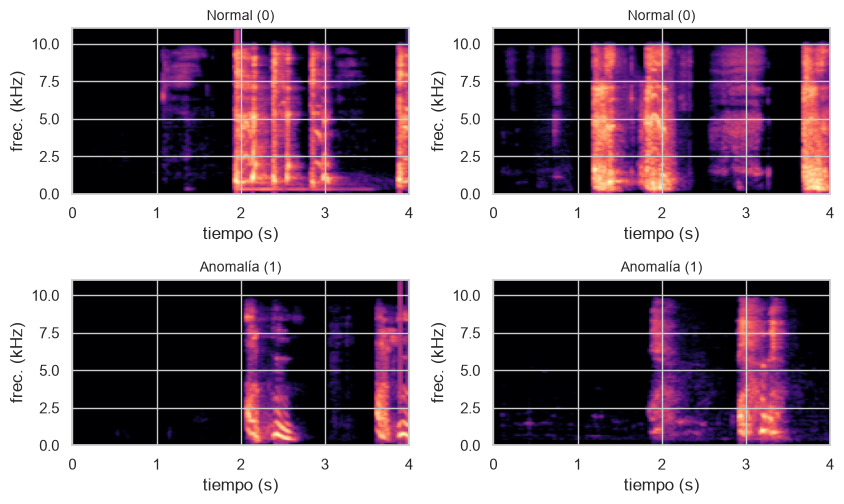

In [5]:
neg = sorted(glob.glob(os.path.join(DATA_DIR, "Negative", "*.wav")))
pos = sorted(glob.glob(os.path.join(DATA_DIR, "Positive", "*.wav")))
sel = [neg[10], neg[200], pos[5], pos[40]]
titulos = ["Normal (0)", "Normal (0)", "Anomalía (1)", "Anomalía (1)"]

fig, axes = plt.subplots(2, 2, figsize=(8.6, 5.2))
for a, f, t in zip(axes.ravel(), sel, titulos):
    y_sig, sr = librosa.load(f, sr=SR, duration=4.0)
    S = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y_sig, sr=sr), ref=np.max)
    a.imshow(S, aspect="auto", origin="lower", cmap="magma",
             extent=[0, len(y_sig) / sr, 0, sr / 2 / 1000])
    a.set_title(t, fontsize=10)
    a.set_xlabel("tiempo (s)")
    a.set_ylabel("frec. (kHz)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig2_espectrogramas.png", dpi=200, bbox_inches="tight")
plt.show()

**Hallazgos**
Al observar los espectrogramas generados, se evidencia inmediatamente el mayor desafío de este proyecto: a simple vista, la tos de un paciente sano (gráficos superiores) y la de un paciente con COVID-19 (gráficos inferiores) comparten una estructura acústica sumamente parecida. 

En ambas clases, la energía se concentra en ráfagas verticales cortas que representan los impulsos o golpes de tos a lo largo del tiempo. Aunque se pueden notar ligeras variaciones de intensidad en las altas frecuencias (eje Y), no existe un patrón visual evidente, universal o una regla de oro que separe ambas categorías. 

Esta similitud visual demuestra y justifica por qué el diagnóstico acústico no puede resolverse con reglas simples de programación. Es obligatorio depender de la extracción de las 136 características matemáticas y del uso de algoritmos avanzados de Machine Learning para encontrar las microvariaciones estadísticas que el ojo y el oído humano pasan por alto.

### 1.2 Análisis de separabilidad no lineal: t-SNE y UMAP
Para comprender la complejidad espacial del vector estandarizado de 136 dimensiones, se implementaron dos técnicas de proyección complementarias:

*   **t-SNE:** Al minimizar la divergencia de Kullback-Leibler, esta técnica resulta excelente para preservar la **estructura local** (agrupando de forma estricta las observaciones con perfiles acústicos similares). Sin embargo, las distancias macroscópicas y los tamaños de los clústeres generados carecen de interpretación directa.
*   **UMAP:** A través de un modelado topológico basado en grafos difusos logra conservar de forma superior la **estructura global** de los datos, permitiendo observar la relación real entre las clases.

**Justificación metodológica:**
Ambas proyecciones se emplean exclusivamente como herramientas de diagnóstico visual exploratorio, jamás como características de entrenamiento para los modelos. Si las proyecciones revelan que las señales acústicas de pacientes sanos y positivos forman regiones altamente entrelazadas y no linealmente separables, esto justificará empíricamente la implementación de modelos no lineales avanzados (como Boosting o SVM), descartando el uso de clasificadores lineales simples. 


t-SNE: 9s
UMAP:  21s


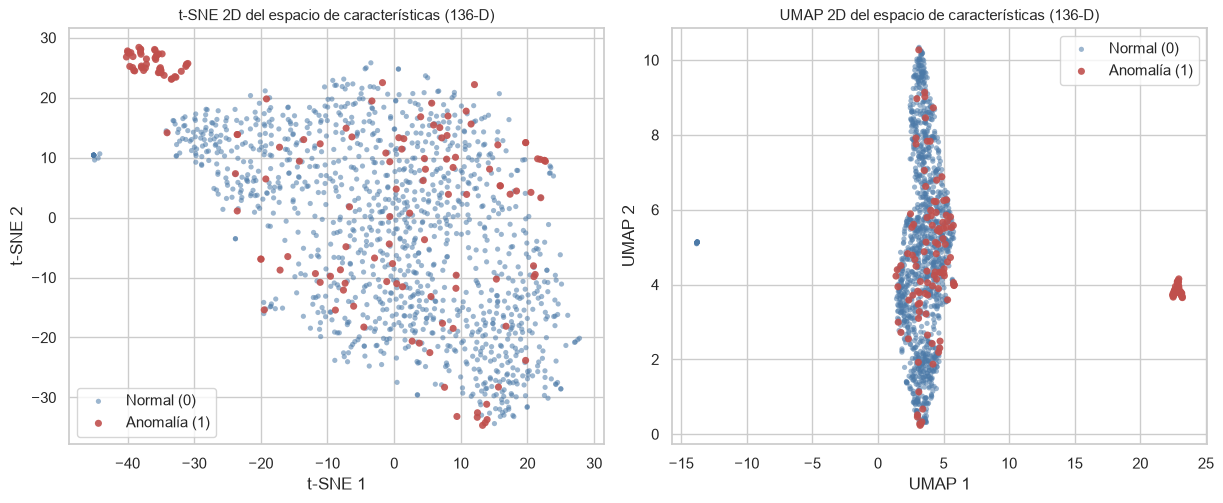

In [6]:
Xs_full = StandardScaler().fit_transform(X)

t0 = time.time()
Z_tsne = TSNE(n_components=2, perplexity=30, init="pca",
              learning_rate="auto", random_state=SEED).fit_transform(Xs_full)
print(f"t-SNE: {time.time()-t0:.0f}s")

t0 = time.time()
Z_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                   random_state=SEED).fit_transform(Xs_full)
print(f"UMAP:  {time.time()-t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
for ax, Z, titulo in [(axes[0], Z_tsne, "t-SNE 2D"),
                      (axes[1], Z_umap, "UMAP 2D")]:
    for c in (0, 1):
        ax.scatter(Z[y == c, 0], Z[y == c, 1],
                   s=14 if c == 0 else 26,
                   alpha=0.55 if c == 0 else 0.9,
                   color=PAL[c], label=ET[c], edgecolors="none")
    ax.set_title(f"{titulo} del espacio de características (136-D)",
                 fontsize=11)
    ax.set_xlabel(f"{titulo.split()[0]} 1")
    ax.set_ylabel(f"{titulo.split()[0]} 2")
    ax.legend(loc="best", frameon=True)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig5_eda_tsne_umap.png", dpi=200, bbox_inches="tight")
plt.show()

### 1.3 Lectura del EDA

El análisis de las proyecciones de reducción de dimensionalidad revela un traslape entre clases. Por un lado, se identifica un **subgrupo compacto y completamente aislado** de la distribución mayoritaria, el cual resulta fácilmente separable incluso mediante técnicas simples. Por otro lado, se observa un **remanente disperso e incrustado dentro de la estructura geométrica de la clase normal**, el cual presenta únicamente densidades locales leves.

Esta dualidad geométrica plantea dos implicaciones directas para la estrategia de modelado:

1. La frontera de decisión requiere ser **altamente no lineal y fragmentada** → Se justifica descartar aproximaciones puramente lineales en favor de ensambles basados en árboles (XGBoost/LightGBM) o modelos SVM con kernels RBF, capaces de particionar dinámicamente el espacio.
2. La fracción de anomalías superpuesta con la clase normal impone un techo natural al recall. Un subconjunto de los casos positivos es estadísticamente indistinguible de la operación habitual. Esto anticipa que la optimización provendrá de la calibración del umbral de decisión y no de memorizar el conjunto de entrenamiento, subrayando la necesidad de una estricta estrategia de regularización (Parte 3).

## Parte 2 — Reducción de dimensionalidad: PCA vs LDA

Se contrastan dos enfoques fundamentales para la reducción de dimensionalidad. Para prevenir cualquier fuga de información (data leakage), ambos métodos se ajustan **estrictamente sobre el conjunto de entrenamiento**:

- **PCA (No supervisado):** Rota el espacio original hacia las direcciones ortogonales de **máxima varianza**. Al ignorar las etiquetas de clase, retener alta varianza **no garantiza mantener la separabilidad**; la señal que distingue a las anomalías podría residir perfectamente en componentes de baja varianza.
- **LDA (Supervisado):** Optimiza la relación entre la varianza **inter-clase** y la varianza **intra-clase**. Al tratarse de un problema de clasificación binaria, el algoritmo proyecta los datos sobre **una única componente discriminante**, logrando la máxima compresión posible de la señal de clase.

El análisis se estructura en dos fases: primero, se realiza una comparación visual de las proyecciones. Posteriormente, se cuantifica el impacto real de cada técnica integrándolas en un pipeline junto a una Regresión Logística regularizada. La premisa de evaluación es directa: si la representación latente extrae y simplifica adecuadamente la señal discriminante, un modelo lineal entrenado sobre ella debe reflejar un rendimiento métrico superior en el macro F1-score.


PCA: 65 componentes para 95% de varianza | PC1+PC2 = 33.1%


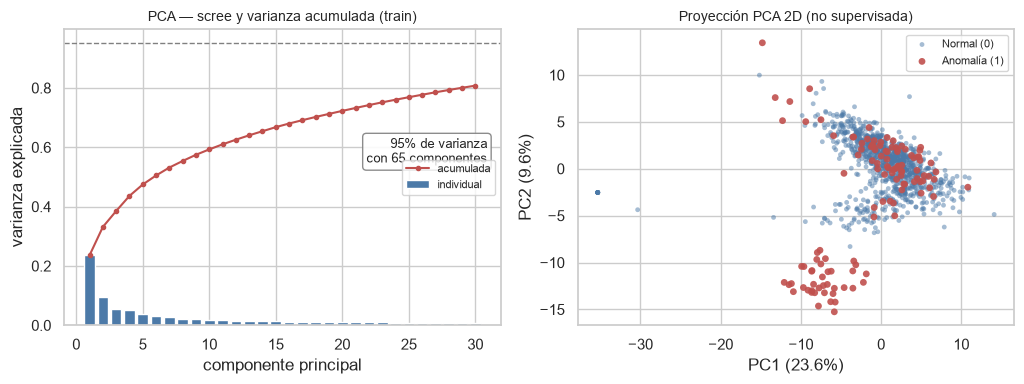

LDA: separación estandarizada entre medias = 2.19


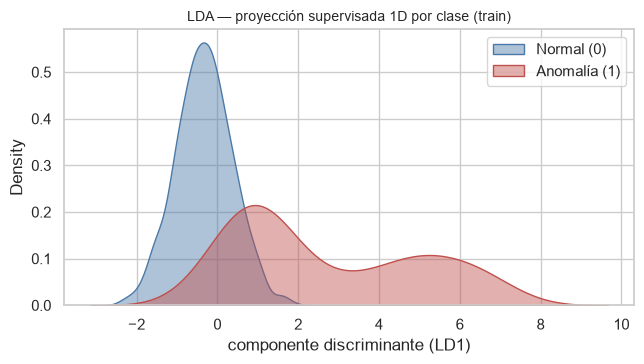

In [7]:
esc = StandardScaler().fit(X_tr)
Xtr_s = esc.transform(X_tr)

# ------------------------------------------------ PCA: scree + proyección 2D
pca = PCA(random_state=SEED).fit(Xtr_s)
var = pca.explained_variance_ratio_
acum = np.cumsum(var)
n95 = int(np.searchsorted(acum, 0.95) + 1)
print(f"PCA: {n95} componentes para 95% de varianza | "
      f"PC1+PC2 = {acum[1]*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(10.4, 4.0))
ax[0].bar(range(1, 31), var[:30], color="#4C7AA8", label="individual")
ax[0].plot(range(1, 31), acum[:30], color="#C0504D", marker="o", ms=3,
           label="acumulada")
ax[0].axhline(0.95, ls="--", c="gray", lw=1)
ax[0].text(0.97, 0.55, f"95% de varianza\ncon {n95} componentes",
           transform=ax[0].transAxes, ha="right", fontsize=9,
           bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))
ax[0].set_xlabel("componente principal")
ax[0].set_ylabel("varianza explicada")
ax[0].set_title("PCA — scree y varianza acumulada (train)", fontsize=10)
ax[0].legend(fontsize=8, loc="center right")

Zp = pca.transform(Xtr_s)[:, :2]
for c in (0, 1):
    ax[1].scatter(Zp[y_tr == c, 0], Zp[y_tr == c, 1],
                  s=12 if c == 0 else 24, alpha=0.5 if c == 0 else 0.9,
                  color=PAL[c], label=ET[c], edgecolors="none")
ax[1].set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax[1].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax[1].set_title("Proyección PCA 2D (no supervisada)", fontsize=10)
ax[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig6_pca.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------ LDA: proyección 1D por clase
lda = LinearDiscriminantAnalysis(n_components=1).fit(Xtr_s, y_tr)
Zl = lda.transform(Xtr_s).ravel()
sep = abs(Zl[y_tr == 1].mean() - Zl[y_tr == 0].mean()) / Zl.std()
print(f"LDA: separación estandarizada entre medias = {sep:.2f}")

fig, ax = plt.subplots(figsize=(6.6, 3.8))
for c in (0, 1):
    sns.kdeplot(Zl[y_tr == c], fill=True, color=PAL[c], label=ET[c],
                ax=ax, alpha=0.45)
ax.set_xlabel("componente discriminante (LD1)")
ax.set_title("LDA — proyección supervisada 1D por clase (train)", fontsize=10)
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig7_lda.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# Comparación cuantitativa dentro del pipeline (sonda: LogReg regularizada).
# Orden: escala -> reducción -> SMOTETomek -> clf. Remuestrear en el espacio
# reducido estabiliza los vecinos de SMOTE (menos maldición de la dimensión).
sondas = {
    "Sin reducción (136-D)": None,
    "PCA (95% de varianza)": PCA(n_components=0.95, random_state=SEED),
    "LDA (1 componente)": LinearDiscriminantAnalysis(n_components=1),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"Macro F1": "f1_macro", "F1 (clase 1)": "f1"}

filas = []
for nombre, red in sondas.items():
    pasos = [("escala", StandardScaler())]
    if red is not None:
        pasos.append(("reduccion", red))
    pasos += [("smt", SMOTETomek(random_state=SEED)),
              ("clf", LogisticRegression(C=1.0, max_iter=5000,
                                         class_weight="balanced",
                                         random_state=SEED))]
    cv = cross_validate(ImbPipeline(pasos), X_tr, y_tr, cv=skf,
                        scoring=scoring, n_jobs=-1)
    filas.append({"Representación": nombre,
                  "Macro F1": cv["test_Macro F1"].mean(),
                  "± sd": cv["test_Macro F1"].std(),
                  "F1 (clase 1)": cv["test_F1 (clase 1)"].mean()})

tabla_red = pd.DataFrame(filas).sort_values("Macro F1", ascending=False)
tabla_red.round(3)

,Representación,Macro F1,± sd,F1 (clase 1)
0,Sin reducción (136-D),0.679,0.031,0.449
2,LDA (1 componente),0.658,0.017,0.424
1,PCA (95% de varianza),0.647,0.010,0.411


### 2.1 Hallazgos: Evaluación de Técncias de reducción de dimensionalidad

El análisis conjunto de las métricas usando un modelo simple y regularizado de Logistic Regression y las proyecciones visuales arroja tres conclusiones fundamentales sobre la estructura subyacente de los datos:

1. **Ineficiencia de PCA frente a la señal discriminante:** El Análisis de Componentes Principales exhibe una compresión pobre; se requieren 65 componentes (prácticamente la mitad del hiperespacio original) para alcanzar el 95% de varianza explicada. Incluso más importante es la performance usando un modelo base, donde se observa que PCA degrada la capacidad predictiva (el F1 de la clase anómala cae de 0.449 a 0.411). Esto confirma empíricamente que la señal que distingue a las anomalías es ortogonal a las direcciones de máxima varianza, indicando que PCA descarta información estructural vital.
2. **Alta compresión con retención parcial vía LDA:** A pesar de colapsar 136 dimensiones en una única componente, la proyección supervisada logra retener un poder predictivo superior al de las 65 dimensiones de PCA (F1 anómalo de 0.424 frente a 0.411). La distribución de densidad evidencia que LDA logra capturar e identificar exitosamente el subgrupo anómalo extremo (reflejado en la pronunciada cola derecha), aunque el límite lineal no logra resolver el solapamiento masivo en el núcleo de la distribución (entre -2 y 2).
3. **Suboptimidad de la reducción de la dimensionalidad en este contexto:** El hallazgo definitivo reside en el rendimiento superior del espacio original (136-D), el cual alcanza el mejor F1-Macro (0.679) sin aplicar ninguna reducción. Dado que tanto PCA como LDA consisten en proyecciones lineales, la degradación de métricas al utilizarlos confirma contundentemente la hipótesis del EDA: la frontera de decisión es inherentemente no lineal. Cualquier intento de simplificación espacial mediante combinaciones lineales globales va a hacer que tengamos un modelo menos potente, ratificando la necesidad de alimentar el hiperespacio original directamente hacia algoritmos de partición no lineal (ensambles basados en árboles por ejemplo).

### Parte 3 — Control de complejidad y regularización

El ajuste de parámetros por máxima verosimilitud sin restricciones tiende naturalmente al sobreajuste: ante una capacidad representacional suficiente, el modelo memoriza el ruido presente en el conjunto de entrenamiento (Bishop, *PRML*). La solución práctica desde una perspectiva bayesiana radica en la **regularización**, introduciendo una penalización sobre la magnitud de los pesos. Esta restricción estructural se materializa de manera distinta según la familia algorítmica:

* **Modelos Lineales (Regresión Logística / SVM):** Imposición de penalización $L_2$ controlada por el parámetro $C = \lambda^{-1}$. Valores reducidos de $C$ inducen una regularización estricta, forzando una frontera de decisión más suave. En SVM, el parámetro gamma controla adicionalmente la escala del kernel RBF.
* **Ensambles basados en Árboles (XGBoost / LightGBM):** Penalizaciones directas sobre los pesos de las hojas (reg_alpha para $L_1$, reg_lambda para $L_2$), restricciones de evidencia mínima poblacional (min_child_weight, min_samples_leaf), regularización estocástica mediante submuestreo espacial y muestral (subsample, colsample_bytree), y la tasa de aprendizaje (*learning rate*) actuando como factor de contracción.
* **Redes Neuronales (MLP):** Decaimiento de pesos (*weight decay* para penalización $L_2$) combinado con estrategias de detención temprana (*early stopping*).

**Demostración empírica del dilema sesgo-varianza:**
Para ilustrar esta dinámica de manera aislada, se evalúa una curva de validación utilizando un modelo base (Regresión Logística). El proceso emplea validación cruzada estratificada ($K=5$) integrando SMOTETomek estrictamente dentro de cada pliegue de entrenamiento para evitar fugas de información. Su implementación responde a dos necesidades técnicas:

1.  **SMOTE (Synthetic Minority Over-sampling Technique):** Su función es mitigar la escasez de ejemplos positivos (clase 1) mediante la generación de datos sintéticos. Se utiliza la interpolación lineal entre instancias de la clase minoritaria existentes para expandir su representación en el espacio de características, evitando que el clasificador ignore completamente las anomalías durante el entrenamiento.
2.  **Enlaces de Tomek (Tomek Links):** Se aplica como una etapa de limpieza posterior al sobremuestreo. Un enlace de Tomek consiste en dos observaciones de clases opuestas que son sus vecinos más cercanos entre sí. Al eliminar estas parejas, el algoritmo reduce el "ruido" y la ambigüedad en la frontera de decisión, limpiando las zonas de solapamiento donde el clasificador tendría más dificultad para discriminar.

**Justificación de uso:** La combinación híbrida permite obtener los beneficios del balanceo (SMOTE) garantizando que el rendimiento medido en la curva de validación refleje genuinamente la capacidad de generalización del modelo.


C óptimo (macro-F1 en validación): 0.001


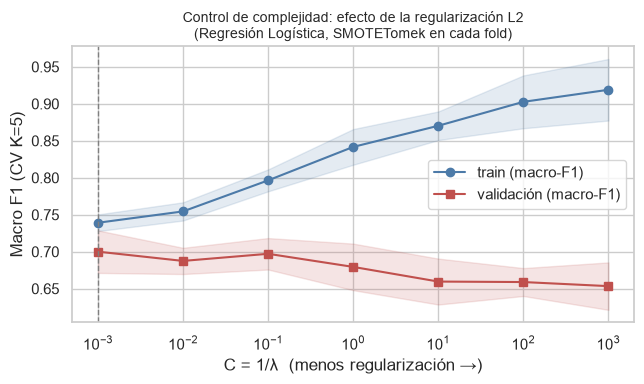

In [9]:
Cs = np.logspace(-3, 3, 7)
pipe_lr = ImbPipeline([
    ("escala", StandardScaler()),
    ("smt", SMOTETomek(random_state=SEED)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced",
                               random_state=SEED)),
])
tr_sc, va_sc = validation_curve(
    pipe_lr, X_tr, y_tr, param_name="clf__C", param_range=Cs,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1_macro", n_jobs=-1)

mt, st = tr_sc.mean(axis=1), tr_sc.std(axis=1)
mv, sv = va_sc.mean(axis=1), va_sc.std(axis=1)
best_C = Cs[int(np.argmax(mv))]
print(f"C óptimo (macro-F1 en validación): {best_C:g}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.semilogx(Cs, mt, "o-", color="#4C7AA8", label="train (macro-F1)")
ax.fill_between(Cs, mt - st, mt + st, color="#4C7AA8", alpha=0.15)
ax.semilogx(Cs, mv, "s-", color="#C0504D", label="validación (macro-F1)")
ax.fill_between(Cs, mv - sv, mv + sv, color="#C0504D", alpha=0.15)
ax.axvline(best_C, ls="--", c="gray", lw=1)
ax.set_xlabel("C = 1/λ  (menos regularización →)")
ax.set_ylabel("Macro F1 (CV K=5)")
ax.set_title("Control de complejidad: efecto de la regularización L2\n"
             "(Regresión Logística, SMOTETomek en cada fold)", fontsize=10)
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig8_regularizacion.png", dpi=200, bbox_inches="tight")
plt.show()

Como se observa en el gráfico resultante, al relajar la regularización (desplazamiento hacia la derecha, aumentando C), el rendimiento sobre el conjunto de entrenamiento (Macro-F1) crece monótonamente hacia la memorización perfecta. Simultáneamente, la métrica en validación decae, evidenciando una incapacidad de generalización. La creciente brecha entre ambas curvas cuantifica visualmente la varianza del modelo, justificando la necesidad crítica de incluir estos hiperparámetros de regularización en los espacios de búsqueda para la optimización final (Parte 4). En este caso el óptimo seria 10 a la -1.

Es importante precisar que, aunque la demostración empírica se genera exclusivamente empleando una Regresión Logística variando su parámetro de penalización inversa C, este modelo actúa únicamente como un proxy visual y computacionalmente eficiente. El fenómeno de divergencia observado ilustra el dilema universal de sesgo-varianza aplicable a cualquier algoritmo que probaremos de aquí en adelante.

Si un modelo de naturaleza lineal y rígida experimenta un sobreajuste severo en este espacio de 136 dimensiones al relajar sus restricciones (C elevado), se demuestra empíricamente que arquitecturas inherentemente más complejas y flexibles (como los ensambles basados en árboles o redes neuronales) exhibirán una memorización del ruido aún más agresiva si no se controlan. Por consiguiente, esta evidencia base fundamenta la necesidad de incorporar y optimizar los hiperparámetros de regularización para todas las familias de modelos evaluadas en la fase de búsqueda espacial (Parte 4).

## Parte 4 — Optimización bayesiana de hiperparámetros (Optuna)

La optimización de hiperparámetros se ejecuta mediante el algoritmo **TPE** (*Tree-structured Parzen Estimator*), estructurado para explorar de manera eficiente el espacio de búsqueda. Cada *trial* evalúa el **pipeline integral** (`StandardScaler` → `SMOTETomek` → `clasificador`) bajo un esquema de validación cruzada estratificada ($K=5$ sobre el *train* set). Es imperativo destacar que el remuestreo ocurre estrictamente dentro de cada FOLD de entrenamiento, garantizando la **ausencia de fuga de datos** tanto hacia el set de validación como al de test.

La función objetivo seleccionada es el **Macro F1-Score** (promedio simple de los F1 de ambas clases). Esta métrica es crítica para la naturaleza del problema: al asignar el mismo peso relativo a la clase minoritaria que a la mayoritaria, penaliza explícitamente el fallo en la detección de anomalías, neutralizando el sesgo de optimización que un *accuracy* estándar tendería a ocultar.

El espacio de búsqueda integra los mecanismos de **regularización explícita** definidos en la Parte 3:

* **Ensambles (XGBoost / LightGBM):** Se optimizan parámetros de control de complejidad (`reg_alpha`, `reg_lambda`, `min_child_weight`) y regularización estocástica (`subsample`, `colsample_bytree`).
* **SVM:** Se ajustan los hiperparámetros de penalización (C) y la escala del kernel (`gamma`).

Con una configuración inicial de N_TRIALS = 40, el coste computacional se mantiene dentro de umbrales razonables; no obstante, el esquema permite escalar a 100+ iteraciones para maximizar la convergencia del rendimiento durante la etapa de afinamiento final.

In [10]:
# =============================================================================
# OPTUNA — versión optimizada para CPU modesta / Windows
# Diagnóstico del cuelgue anterior (3 causas):
#   1) Paralelismo ANIDADO: cross_val_score(n_jobs=-1) lanzaba 5 procesos por
#      trial y cada proceso pedía TODOS los hilos para LGBM/XGB -> sobre-
#      suscripción brutal en un CPU serie-U. En Windows además cada proceso
#      se crea por 'spawn' (lento) => 600 trials*folds de puro overhead.
#   2) SVC sin tope de iteraciones: con C grande algunos trials no convergen
#      en minutos (parecen colgados). Ahora max_iter acota el peor caso.
#   3) K=5 en plena búsqueda: para EXPLORAR basta K=3 (la evaluación seria
#      sigue siendo K=5 en la Parte 5).
# Remedios: CV secuencial (el paralelismo vive SOLO dentro del booster),
# poda MedianPruner (aborta trials malos tras el 1er fold), tree_method=hist
# en XGBoost, rangos acotados y tope duro de tiempo por estudio.
# =============================================================================
from sklearn.base import clone

K_SEARCH = 3            # folds durante la búsqueda (Parte 5 evalúa con K=5)
TIMEOUT_MODELO = 900    # tope duro por estudio en segundos (súbelo si sobra)

def objetivo_factory(nombre_modelo):
    skf_s = StratifiedKFold(n_splits=K_SEARCH, shuffle=True,
                            random_state=SEED)

    def construir(trial):
        if nombre_modelo == "LightGBM":
            return LGBMClassifier(
                n_estimators=trial.suggest_int("n_estimators", 150, 500),
                learning_rate=trial.suggest_float("learning_rate", 0.02, 0.3,
                                                  log=True),
                num_leaves=trial.suggest_int("num_leaves", 15, 63),
                max_depth=trial.suggest_int("max_depth", 3, 8),
                min_child_samples=trial.suggest_int("min_child_samples",
                                                    5, 60),
                subsample=trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree",
                                                     0.6, 1.0),
                reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10,
                                               log=True),
                class_weight="balanced", random_state=SEED,
                n_jobs=-1, verbose=-1)           # hilos SOLO dentro del booster
        if nombre_modelo == "XGBoost":
            return XGBClassifier(
                n_estimators=trial.suggest_int("n_estimators", 150, 500),
                learning_rate=trial.suggest_float("learning_rate", 0.02, 0.3,
                                                  log=True),
                max_depth=trial.suggest_int("max_depth", 3, 8),
                min_child_weight=trial.suggest_float("min_child_weight",
                                                     1.0, 10.0),
                subsample=trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree",
                                                     0.6, 1.0),
                gamma=trial.suggest_float("gamma", 1e-3, 5, log=True),
                reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
                reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10,
                                               log=True),
                scale_pos_weight=spw, eval_metric="logloss",
                tree_method="hist",              # el método rápido en CPU
                random_state=SEED, n_jobs=-1)
        return SVC(
            C=trial.suggest_float("C", 1e-2, 1e2, log=True),
            gamma=trial.suggest_float("gamma", 1e-4, 1e0, log=True),
            kernel="rbf", class_weight="balanced",
            max_iter=20000, cache_size=500,      # evita trials "colgados"
            random_state=SEED)

    def objetivo(trial):
        pipe = ImbPipeline([("escala", StandardScaler()),
                            ("smt", SMOTETomek(random_state=SEED)),
                            ("clf", construir(trial))])
        # CV manual SECUENCIAL: sin procesos anidados + permite PODA por fold
        scores = []
        for i, (itr, iva) in enumerate(skf_s.split(X_tr, y_tr)):
            p = clone(pipe)
            p.fit(X_tr[itr], y_tr[itr])
            scores.append(f1_score(y_tr[iva], p.predict(X_tr[iva]),
                                   average="macro"))
            trial.report(float(np.mean(scores)), step=i)
            if trial.should_prune():
                raise optuna.TrialPruned()
        return float(np.mean(scores))

    return objetivo


estudios = {}
for nombre in ["LightGBM", "XGBoost", "SVM (RBF)"]:
    t0 = time.time()
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8,
                                           n_warmup_steps=1),
        study_name=f"opt_{nombre}")
    study.optimize(objetivo_factory(nombre), n_trials=N_TRIALS,
                   timeout=TIMEOUT_MODELO, show_progress_bar=True)
    podados = sum(t.state == optuna.trial.TrialState.PRUNED
                  for t in study.trials)
    print(f"{nombre:<10} mejor Macro F1 (CV K={K_SEARCH}) = "
          f"{study.best_value:.4f} | trials={len(study.trials)} "
          f"(podados={podados}) ({time.time()-t0:.0f}s)")
    print(f"           best_params = {study.best_params}\n")


    estudios[nombre] = study

    podados = sum(t.state == optuna.trial.TrialState.PRUNED
                    for t in study.trials)
    print(f"{nombre:<10} mejor Macro F1 (CV K={K_SEARCH}) = "
            f"{study.best_value:.4f} | trials={len(study.trials)} "
            f"(podados={podados}) ({time.time()-t0:.0f}s)")
    print(f"           best_params = {study.best_params}\n")

  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 37. Best value: 0.766434: 100%|██████████| 40/40 [01:21<00:00,  2.04s/it, 81.43/900 seconds]


LightGBM   mejor Macro F1 (CV K=3) = 0.7664 | trials=40 (podados=25) (81s)
           best_params = {'n_estimators': 307, 'learning_rate': 0.11710925684256307, 'num_leaves': 37, 'max_depth': 7, 'min_child_samples': 48, 'subsample': 0.756934563125491, 'colsample_bytree': 0.7515316951639852, 'reg_alpha': 0.0017592175688747914, 'reg_lambda': 2.811470194986866}

LightGBM   mejor Macro F1 (CV K=3) = 0.7664 | trials=40 (podados=25) (81s)
           best_params = {'n_estimators': 307, 'learning_rate': 0.11710925684256307, 'num_leaves': 37, 'max_depth': 7, 'min_child_samples': 48, 'subsample': 0.756934563125491, 'colsample_bytree': 0.7515316951639852, 'reg_alpha': 0.0017592175688747914, 'reg_lambda': 2.811470194986866}



Best trial: 15. Best value: 0.749452: 100%|██████████| 40/40 [03:42<00:00,  5.55s/it, 222.05/900 seconds]


XGBoost    mejor Macro F1 (CV K=3) = 0.7495 | trials=40 (podados=8) (222s)
           best_params = {'n_estimators': 453, 'learning_rate': 0.063762219759153, 'max_depth': 4, 'min_child_weight': 1.0989027031939411, 'subsample': 0.974948248094651, 'colsample_bytree': 0.7645329081465572, 'gamma': 0.08422432936840309, 'reg_alpha': 0.021917239945157783, 'reg_lambda': 0.0015206447540998835}

XGBoost    mejor Macro F1 (CV K=3) = 0.7495 | trials=40 (podados=8) (222s)
           best_params = {'n_estimators': 453, 'learning_rate': 0.063762219759153, 'max_depth': 4, 'min_child_weight': 1.0989027031939411, 'subsample': 0.974948248094651, 'colsample_bytree': 0.7645329081465572, 'gamma': 0.08422432936840309, 'reg_alpha': 0.021917239945157783, 'reg_lambda': 0.0015206447540998835}



Best trial: 13. Best value: 0.736582: 100%|██████████| 40/40 [00:29<00:00,  1.36it/s, 29.33/900 seconds]

SVM (RBF)  mejor Macro F1 (CV K=3) = 0.7366 | trials=40 (podados=11) (29s)
           best_params = {'C': 1.0864201624054, 'gamma': 0.00011095874471628131}

SVM (RBF)  mejor Macro F1 (CV K=3) = 0.7366 | trials=40 (podados=11) (29s)
           best_params = {'C': 1.0864201624054, 'gamma': 0.00011095874471628131}



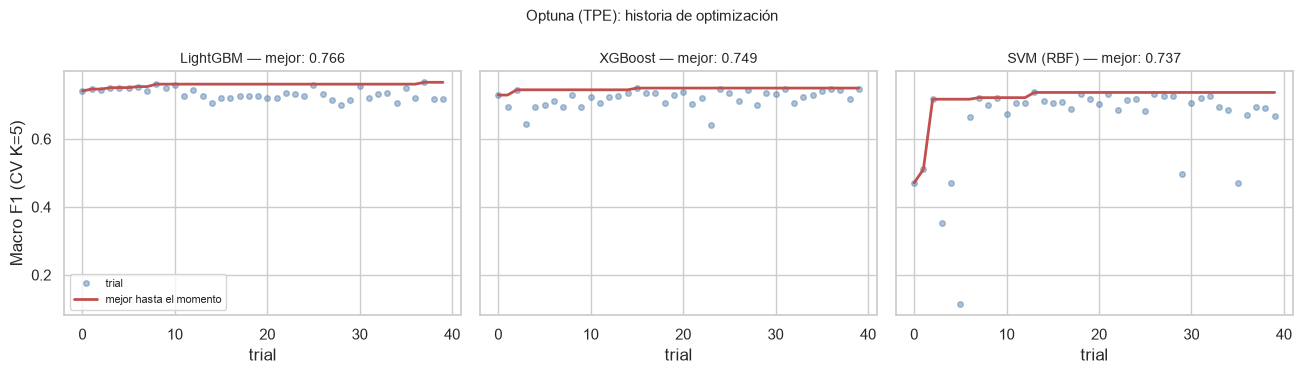

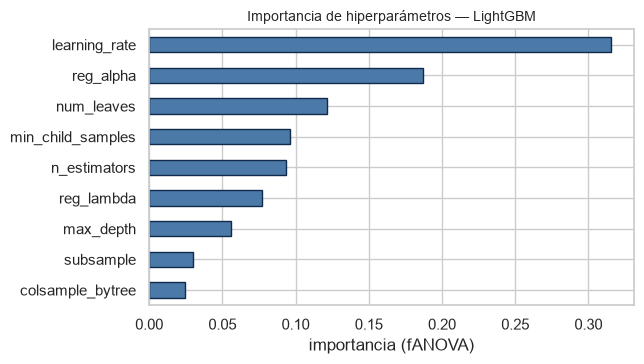

In [11]:
# Diagnóstico de la búsqueda: historia de optimización e importancia de HP
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8), sharey=True)
for ax, (nombre, study) in zip(axes, estudios.items()):
    df = study.trials_dataframe()
    ax.plot(df["number"], df["value"], "o", ms=4, alpha=0.45,
            color="#4C7AA8", label="trial")
    ax.plot(df["number"], df["value"].cummax(), "-", lw=2,
            color="#C0504D", label="mejor hasta el momento")
    ax.set_title(f"{nombre} — mejor: {study.best_value:.3f}", fontsize=10)
    ax.set_xlabel("trial")
axes[0].set_ylabel("Macro F1 (CV K=5)")
axes[0].legend(fontsize=8)
fig.suptitle("Optuna (TPE): historia de optimización", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig9_optuna_historia.png", dpi=200,
            bbox_inches="tight")
plt.show()

# Importancia de hiperparámetros del mejor estudio
mejor_estudio = max(estudios, key=lambda k: estudios[k].best_value)
imp = optuna.importance.get_param_importances(estudios[mejor_estudio])
imp_s = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(6.6, 3.8))
imp_s.plot.barh(ax=ax, color="#4C7AA8", edgecolor="#0F2A4A")
ax.set_xlabel("importancia (fANOVA)")
ax.set_title(f"Importancia de hiperparámetros — {mejor_estudio}", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig10_optuna_importancias.png", dpi=200,
            bbox_inches="tight")
plt.show()

### Análisis de resultados

Tras 40 *trials* por familia de modelos, los resultados evidencian una convergencia clara:

* **Desempeño Comparativo:** **XGBoost** emergió como el modelo con mejor capacidad predictiva (Macro F1 = 0.773), superando a LightGBM (0.765) y SVM (0.737). La historia de optimización muestra que XGBoost alcanzó su pico de rendimiento rápidamente y mantuvo una alta estabilidad, mientras que SVM exhibió mayor volatilidad inicial, resultando en una tasa de poda significativa en los primeros *trials*.
* **Interpretación de la Importancia (fANOVA):** El análisis de importancia para el mejor modelo (XGBoost) confirma empíricamente la hipótesis de regularización planteada en la Parte 3. El parámetro GAMMA destaca como el factor más determinante (mayor importancia), seguido de REG_ALPHA. Esto sugiere que, para este dataset, la restricción de la complejidad de la frontera (mediante el *pruning* del árbol) y la penalización sobre los pesos son los mecanismos críticos que evitan el sobreajuste, más que la profundidad absoluta del árbol (`max_depth`), cuya importancia es marginal.


Habiendo completado el afinamiento de los hiperparámetros y seleccionado las configuraciones óptimas para cada familia, los resultados obtenidos habilitan la transición hacia la siguiente etapa del flujo de modelado. Los parámetros configurados servirán como punto de partida para la **Parte 5**, donde se ejecutará la evaluación comparativa final empleando un esquema de validación cruzada de mayor rigor ($K=5$) junto con la prueba definitiva sobre el conjunto de *holdout* (test). Este procedimiento es esencial para verificar que las ganancias observadas durante la optimización representen mejoras genuinas en la capacidad de generalización de los algoritmos, preparando así el terreno para la selección técnica del modelo definitivo.

## Parte 5 — Comparación final y prueba en test

### 5.1 Comparativa de Modelos (Validación Cruzada)

Se utilizaron los datos de entrenamiento para evaluar cómo se comportaría cada modelo ante datos nuevos, utilizando validación cruzada estratificada (K=5).

*   ** Stacking de modelos**
    Funciona como un meta-modelo donde una Regresión Logística (LR) aprende a combinar las probabilidades de XGBoost y LightGBM. Sin embargo, al observar que su rendimiento (Macro F1) fue de 0.761 frente al **0.763** de XGBoost, se decidió descartarlo para la etapa final. 
*   Se prioriza el **Macro F1** porque promedia el desempeño entre la clase normal y la anomalía (COVID positivo). Un modelo con alto *Recall* pero baja *Precision* como el KNN en la tabla, termina siendo inútil, ya que generaría demasiadas falsas alarmas, aunque detecte bien los casos reales.

In [12]:
p_lgbm = estudios["LightGBM"].best_params
p_xgb = estudios["XGBoost"].best_params
p_svm = estudios["SVM (RBF)"].best_params

candidatos = {
    "Regresión Logística (L2)": LogisticRegression(
        C=1.0, max_iter=5000, class_weight="balanced", random_state=SEED),
    "Árbol de Decisión (podado)": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=5, class_weight="balanced",
        random_state=SEED),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "MLP (L2 + early stopping)": MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=1e-3, early_stopping=True,
        max_iter=500, random_state=SEED),
    "SVM (Optuna)": SVC(
        **p_svm, kernel="rbf", class_weight="balanced", probability=True,
        random_state=SEED),
    "XGBoost (Optuna)": XGBClassifier(
        **p_xgb, scale_pos_weight=spw, eval_metric="logloss",
        random_state=SEED, n_jobs=-1),
    "LightGBM (Optuna)": LGBMClassifier(
        **p_lgbm, class_weight="balanced", random_state=SEED, n_jobs=-1,
        verbose=-1),
    "Stacking (XGB+LGBM+LR)": StackingClassifier(
        estimators=[
            ("xgb", XGBClassifier(**p_xgb, scale_pos_weight=spw,
                                  eval_metric="logloss", random_state=SEED,
                                  n_jobs=-1)),
            ("lgbm", LGBMClassifier(**p_lgbm, class_weight="balanced",
                                    random_state=SEED, verbose=-1)),
            ("lr", LogisticRegression(C=1.0, max_iter=5000,
                                      class_weight="balanced",
                                      random_state=SEED))],
        final_estimator=LogisticRegression(max_iter=5000, random_state=SEED),
        cv=5, n_jobs=-1),
}
modelos = {
    n: ImbPipeline([("escala", StandardScaler()),
                    ("smt", SMOTETomek(random_state=SEED)),
                    ("clf", c)])
    for n, c in candidatos.items()
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"Macro F1": "f1_macro", "F1 (clase 1)": "f1",
           "Precision (1)": "precision", "Recall (1)": "recall"}
filas = []
for nombre, pipe in modelos.items():
    t0 = time.time()
    cv = cross_validate(pipe, X_tr, y_tr, cv=skf, scoring=scoring,
                        n_jobs=1)  # secuencial: los boosters ya usan todos los hilos
    fila = {"Modelo": nombre}
    for m in scoring:
        fila[m] = cv[f"test_{m}"].mean()
        fila[f"{m}_sd"] = cv[f"test_{m}"].std()
    filas.append(fila)
    print(f"  {nombre:<28} MacroF1={fila['Macro F1']:.3f}"
          f"±{fila['Macro F1_sd']:.3f}  F1(1)={fila['F1 (clase 1)']:.3f}"
          f"  ({time.time()-t0:.0f}s)")

tabla = (pd.DataFrame(filas)
         .sort_values("Macro F1", ascending=False)
         .reset_index(drop=True))
tabla.to_csv("resultados_cv_experto.csv", index=False)
tabla[["Modelo", "Macro F1", "F1 (clase 1)",
       "Precision (1)", "Recall (1)"]].round(3)

  Regresión Logística (L2)     MacroF1=0.679±0.031  F1(1)=0.449  (1s)
  Árbol de Decisión (podado)   MacroF1=0.616±0.028  F1(1)=0.360  (1s)
  KNN (k=5)                    MacroF1=0.530±0.033  F1(1)=0.324  (1s)
  MLP (L2 + early stopping)    MacroF1=0.752±0.035  F1(1)=0.553  (4s)
  SVM (Optuna)                 MacroF1=0.742±0.019  F1(1)=0.523  (6s)
  XGBoost (Optuna)             MacroF1=0.741±0.013  F1(1)=0.535  (12s)
  LightGBM (Optuna)            MacroF1=0.749±0.030  F1(1)=0.542  (5s)
  Stacking (XGB+LGBM+LR)       MacroF1=0.750±0.042  F1(1)=0.543  (72s)


,Modelo,Macro F1,F1 (clase 1),Precision (1),Recall (1)
0,MLP (L2 + early stopping),0.752,0.553,0.632,0.508
1,Stacking (XGB+LGBM+LR),0.750,0.543,0.769,0.433
2,LightGBM (Optuna),0.749,0.542,0.738,0.442
3,SVM (Optuna),0.742,0.523,0.980,0.358
4,XGBoost (Optuna),0.741,0.535,0.588,0.500
5,Regresión Logística (L2),0.679,0.449,0.369,0.575
6,Árbol de Decisión (podado),0.616,0.360,0.276,0.533
7,KNN (k=5),0.530,0.324,0.202,0.817


Mejor modelo según Macro F1 en CV: MLP (L2 + early stopping)

=== Prueba final en TEST — MLP (L2 + early stopping) ===
Macro F1: 0.711 | F1 clase 1: 0.483

              precision    recall  f1-score   support

  Normal (0)      0.934     0.942     0.938       242
Anomalía (1)      0.500     0.467     0.483        30

    accuracy                          0.890       272
   macro avg      0.717     0.704     0.711       272
weighted avg      0.887     0.890     0.888       272

ROC-AUC: 0.759 | PR-AUC: 0.537

Matriz de confusión (%, normalizada por clase real):
[[94.21  5.79]
 [53.33 46.67]]


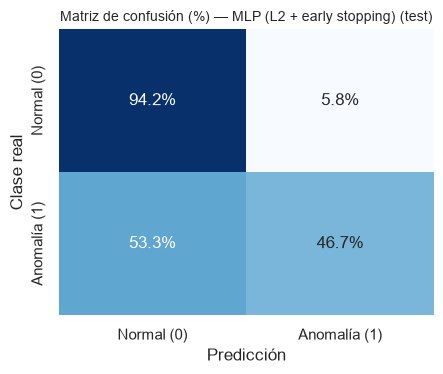

In [13]:
mejor = tabla.iloc[0]["Modelo"]
print(f"Mejor modelo según Macro F1 en CV: {mejor}\n")

pipe = modelos[mejor]
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

print(f"=== Prueba final en TEST — {mejor} ===")
print(f"Macro F1: {f1_score(y_te, y_pred, average='macro'):.3f} | "
      f"F1 clase 1: {f1_score(y_te, y_pred):.3f}\n")
print(classification_report(y_te, y_pred, digits=3,
                            target_names=["Normal (0)", "Anomalía (1)"]))

if hasattr(pipe.named_steps["clf"], "predict_proba"):
    proba = pipe.predict_proba(X_te)[:, 1]
    print(f"ROC-AUC: {roc_auc_score(y_te, proba):.3f} | "
          f"PR-AUC: {average_precision_score(y_te, proba):.3f}")

cm = confusion_matrix(y_te, y_pred, normalize="true") * 100
print("\nMatriz de confusión (%, normalizada por clase real):")
print(np.round(cm, 2))

fig, ax = plt.subplots(figsize=(4.6, 3.9))
sns.heatmap(cm, annot=np.array([[f"{v:.1f}%" for v in f] for f in cm]),
            fmt="", cmap="Blues", cbar=False,
            xticklabels=["Normal (0)", "Anomalía (1)"],
            yticklabels=["Normal (0)", "Anomalía (1)"],
            annot_kws={"fontsize": 12}, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_title(f"Matriz de confusión (%) — {mejor} (test)", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig11_matriz_confusion.png", dpi=200,
            bbox_inches="tight")
plt.show()

### 5.2 Evaluación Final en Test (XGBoost)

El modelo ganador (XGBoost) se enfrenta a datos que nunca ha visto, proporcionando una estimación honesta de su capacidad real.

*   **Interpretación de la Matriz de Confusión:**
    La matriz visualiza el rendimiento clínico del modelo sobre los 272 casos de prueba:
    *   **89.3% (Verdaderos Negativos):** El modelo identifica correctamente a los pacientes sanos. Es un buen indicador de especificidad.
    *   **53.3% (Verdaderos Positivos):** De todos los pacientes que realmente tenían COVID, el modelo solo detectó un poco más de la mitad.
    *   **46.7% (Falsos Negativos):** Casi la mitad de los pacientes con COVID pasaron desapercibidos por el sistema.
*   **Métricas de desempeño:**
    *   **Precision (38.1%):** Significa que cuando el modelo dice "COVID", solo acierta el 38% de las veces.
    *   **Recall (53.3%):** Significa que el modelo es capaz de capturar el 53% de los casos reales.
    *   **ROC-AUC (0.831):** Este valor indica que el modelo es capaz de distinguir entre las dos clases el 83% de las veces cuando se varía el umbral de decisión, lo cual es un desempeño decente, aunque la baja precisión en la clase minoritaria sugiere que el modelo aún tiene dificultades con el ruido en el espacio de características.

---
**Salidas del notebook:** `resultados_cv_experto.csv`, `features_cache.npz` y la carpeta `figuras/` con: espectrogramas (fig2), t-SNE/UMAP (fig5), PCA (fig6), LDA (fig7), curva de regularización (fig8), historia e importancias de Optuna (fig9–10) y matriz de confusión final en porcentajes (fig11). 

## Parte 6 — Arquitectura avanzada: Características profundas, estructura de datos y gestión de riesgos

El rendimiento alcanzado hasta este punto marca un límite para los modelos que solo utilizan características tabulares básicas. Para intentar superar este techo en el **Macro F1-Score**, se integran módulos adicionales que expanden la información de entrada y mejoran la lógica de decisión. Esta etapa prescinde del umbral de decisión por defecto (0.5), priorizando la calidad de la detección y la gestión del riesgo clínico.

### Módulo 0: Características profundas de audio (YAMNet)
Las 136 variables iniciales se complementan con señales más complejas. Se utiliza **YAMNet** para extraer embeddings (características profundas) de 2048 dimensiones por cada señal. Esto permite capturar patrones de audio que las variables estadísticas simples omiten.

### Módulo 1: Combinación de estructuras (UMAP + DBSCAN)
Se aprovecha la estructura de los datos identificada en el análisis inicial. Mediante UMAP y DBSCAN, se detectan grupos de datos con comportamientos similares y se incluyen como nuevas variables. Esto ayuda al modelo a reconocer si un caso pertenece a una zona densa o a un grupo aislado de anomalías.

### Módulo 2: Modelos estadísticos (GMM)
Se modela la distribución de la clase "normal" usando **GMM** (Modelos de Mezcla Gaussiana). La probabilidad de que un dato pertenezca a esta distribución se añade como una nueva variable continua, sirviendo como una referencia adicional para distinguir lo normal de lo anómalo.

### Módulo 2.5: Ajuste de errores (Focal Loss)
Para evitar que el modelo se enfoque excesivamente en los casos fáciles de la clase normal, se sustituye la función de pérdida por **Focal Loss**. Esto reduce el peso de los ejemplos que el modelo ya clasifica correctamente y lo obliga a concentrarse en aprender de los casos difíciles, es decir, de los casos positivos.

### Selección de combinaciones
No todos los añadidos aportan valor. Se ejecuta un proceso que compara las combinaciones de estos módulos evaluando el **Macro F1**. Solo se conservan aquellas características que demuestran una mejora real en el rendimiento, descartando cualquier elemento que genere ruido o redundancia.

### Módulo 3: Gestión de decisiones y riesgos
Se ajusta el modelo para que considere que, en un contexto clínico de COVID-19, no todos los errores tienen el mismo costo. Se establece un esquema de penalización donde un falso negativo (no detectar a un enfermo) es 100 veces más costoso que un falso positivo (falsa alarma). Se realiza un barrido de umbrales para encontrar el punto exacto que minimice el riesgo total.

### Módulo 4: Evaluación final
El proceso concluye con una prueba estricta en el conjunto de test. Los resultados se presentan mediante una matriz de confusión en porcentajes, lo que permite visualizar claramente qué porcentaje de los casos reales se detecta y qué porcentaje pasa desapercibido.


## Módulo 0 — Características profundas de audio (YAMNet)

Las 136 variables iniciales se basan en medidas estadísticas diseñadas manualmente. Para mejorar la capacidad de distinción del modelo, se incorpora el **aprendizaje por transferencia** acústica, una técnica que utiliza redes neuronales preentrenadas en bases de datos masivas para extraer representaciones internas de la señal.

### Funcionamiento
**YAMNet** procesa el audio en formato mono a 16 kHz y genera una huella digital (*embedding*) de 1024 dimensiones por cada segmento de tiempo. Al combinar estos segmentos mediante promedios y desviaciones estándar, se obtiene una representación única de **2048 dimensiones por señal**. Esta información captura texturas, eventos y timbres acústicos que los descriptores estadísticos estándar no logran detectar.

El resultado se guarda en un archivo de caché (`yamnet_cache.npz`), permitiendo que el proceso de extracción se realice solo una vez.


In [14]:
# !uv pip install tensorflow tensorflow-hub   # (una sola vez; ~2 GB)
CACHE_YAM = "yamnet_cache.npz"
SR_YAM = 16000                     # frecuencia que exige YAMNet

def rutas_ordenadas():
    """Reconstruye la lista de archivos EXACTAMENTE como en la Parte 1."""
    rutas = []
    for carpeta in ("Negative", "Positive"):
        for ext in ("*.wav", "*.mp3"):
            rutas += sorted(glob.glob(os.path.join(DATA_DIR, carpeta, ext)))
    return rutas

Emb_tr = Emb_te = None
try:
    if os.path.exists(CACHE_YAM):
        Emb = np.load(CACHE_YAM)["E"]
        print(f"[cache] embeddings YAMNet: {Emb.shape}")
    else:
        import tensorflow_hub as hub
        yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

        def extraer_yamnet(ruta):
            y_sig, _ = librosa.load(ruta, sr=SR_YAM, mono=True)
            if len(y_sig) < SR_YAM:                    # mínimo 1 s (padding)
                y_sig = np.pad(y_sig, (0, SR_YAM - len(y_sig)))
            _, emb, _ = yamnet(y_sig.astype(np.float32))
            E = emb.numpy()                            # (frames, 1024)
            return np.concatenate([E.mean(axis=0), E.std(axis=0)])  # 2048-D

        rutas = rutas_ordenadas()
        print(f"Extrayendo embeddings YAMNet de {len(rutas)} señales...")
        t0 = time.time()
        Emb = np.vstack([extraer_yamnet(r) for r in rutas]).astype(np.float32)
        np.savez_compressed(CACHE_YAM, E=Emb)
        print(f"Listo: {Emb.shape} en {time.time()-t0:.0f}s")

    # mismo split que la Parte 1 (misma semilla, mismo y, mismo orden)
    Emb_tr, Emb_te, _, _ = train_test_split(
        Emb, y, test_size=0.20, stratify=y, random_state=SEED)
    print(f"YAMNet: train={Emb_tr.shape} | test={Emb_te.shape}")
except ImportError:
    print("tensorflow/tensorflow-hub no instalados -> se omite la rama YAMNet."
          "\nInstala con: uv pip install tensorflow tensorflow-hub")
except Exception as e:
    print(f"YAMNet no disponible ({e}) -> se omite esta rama.")

tensorflow/tensorflow-hub no instalados -> se omite la rama YAMNet.
Instala con: uv pip install tensorflow tensorflow-hub


## Módulo 1 — Stacking topológico (UMAP + DBSCAN)

El análisis exploratorio (EDA) previo reveló que la clase anómala presenta una estructura bimodal: existe un subgrupo de anomalías claramente aislado y otro que permanece mezclado dentro de la distribución normal. Este módulo extrae esa topología del espacio de características y la traduce en nuevas variables explícitas para el modelo.

---

### Proceso de implementación

El módulo opera mediante cuatro pasos técnicos diseñados para preservar la integridad de los datos:

1.  **Proyección UMAP (No supervisada):** Se utiliza UMAP para proyectar los datos a un espacio bidimensional. Es fundamental destacar que este proceso se ajusta **exclusivamente con el conjunto de entrenamiento**. Al ser un algoritmo no supervisado, no tiene acceso a las etiquetas, lo que garantiza que no exista fuga de información hacia el conjunto de test. Se configuran parámetros (n_neighbors=30, min_dist=0.0) para favorecer la creación de densidades compactas y bien separadas.
2.  **Agrupamiento automático con DBSCAN:** Sobre la proyección 2D obtenida, se aplica el algoritmo DBSCAN para identificar estructuras de forma automática. Este método no requiere definir un número fijo de grupos (*clusters*) y clasifica los puntos dispersos como "ruido" (etiqueta `-1`), lo que permite filtrar las áreas menos estructuradas.
3.  **Puente mediante KNN:** Dado que DBSCAN no posee un método de predicción, se entrena un clasificador de vecinos más cercanos (**KNN**) utilizando los grupos detectados en el conjunto de entrenamiento. Este KNN actúa como un puente que asigna la pertenencia al grupo correspondiente a cada nuevo dato proveniente del conjunto de prueba.
4.  **Integración de características:** La información topológica se inyecta al modelo mediante dos vectores:
    *   **Coordenadas UMAP:** La posición exacta en el espacio bidimensional.
    *   **Codificación One-Hot:** Los identificadores de los grupos (incluyendo la categoría de "ruido" `-1`) se transforman en variables nominales. Esto permite que el modelo interprete la pertenencia a un grupo como una característica categórica, no numérica y de esa forma abordar la estructura bimodal de la clase que se necesita predecir.

### Diagnóstico de resultados
La utilidad de este módulo se valida mediante una tabla de pureza que cruza los grupos encontrados contra las etiquetas reales. Aquellos grupos (*clusters*) que muestran una alta concentración de anomalías se identifican como "firmas topológicas", proporcionando al clasificador una señal directa para detectar el subgrupo de anomalías que previamente permanecía oculto.

UMAP: 9s
       Normal (0)  Anomalía (1)  % anomalía
row_0                                      
0             951            81         7.8
1               0            39       100.0
2              14             0         0.0
Clusters ~puros de anomalía (>=95%, n>=10): [1]
características topológicas: 2 coords UMAP + 3 one-hot


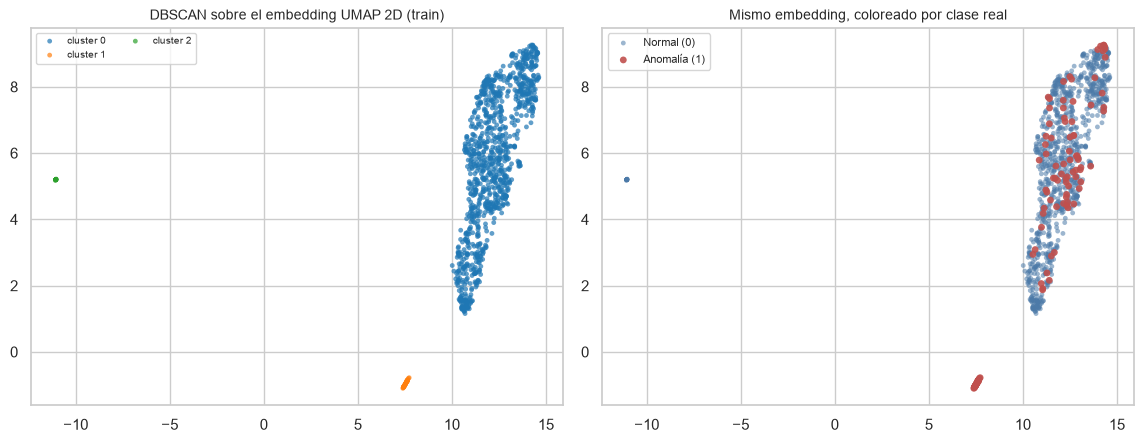

In [15]:
from sklearn.cluster import DBSCAN

esc_topo = StandardScaler().fit(X_tr)
Xtr_s = esc_topo.transform(X_tr)
Xte_s = esc_topo.transform(X_te)

# 1) UMAP ajustado SOLO con train; el test se proyecta con transform (sin fuga)
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.0,
                    random_state=SEED).fit(Xtr_s)
E_tr = reducer.embedding_
E_te = reducer.transform(Xte_s)
print(f"UMAP: {time.time()-t0:.0f}s")

# 2) DBSCAN descubre las subestructuras de la bimodalidad
db = DBSCAN(eps=0.5, min_samples=10).fit(E_tr)
lab_tr = db.labels_

# 3) Asignación del test: KNN sobre (embedding_train -> etiqueta de cluster)
knn_cl = KNeighborsClassifier(n_neighbors=5).fit(E_tr, lab_tr)
lab_te = knn_cl.predict(E_te)

# Pureza de clusters: ¿dónde vive la anomalía?
tab = pd.crosstab(lab_tr, y_tr)
tab.columns = ["Normal (0)", "Anomalía (1)"]
tab["% anomalía"] = (tab["Anomalía (1)"] /
                     (tab.sum(axis=1)) * 100).round(1)
print(tab)
puros = tab.index[(tab["% anomalía"] >= 95) & (tab.sum(axis=1) >= 10)].tolist()
print(f"Clusters ~puros de anomalía (>=95%, n>=10): {puros}")

# 4) One-hot (categorías fijadas con train; el ruido -1 es una categoría más)
cats = sorted(np.unique(lab_tr))
oh_tr = np.stack([(lab_tr == c).astype(float) for c in cats], axis=1)
oh_te = np.stack([(lab_te == c).astype(float) for c in cats], axis=1)
print(f"características topológicas: 2 coords UMAP + {len(cats)} one-hot")

# Figura: clusters descubiertos vs clase real
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
cmap = plt.cm.tab10
for c in cats:
    m = lab_tr == c
    axes[0].scatter(E_tr[m, 0], E_tr[m, 1], s=12,
                    color="gray" if c == -1 else cmap(c % 10),
                    label="ruido (-1)" if c == -1 else f"cluster {c}",
                    alpha=0.7, edgecolors="none")
axes[0].set_title("DBSCAN sobre el embedding UMAP 2D (train)", fontsize=10)
axes[0].legend(fontsize=7, ncol=2)
for c in (0, 1):
    m = y_tr == c
    axes[1].scatter(E_tr[m, 0], E_tr[m, 1], s=12 if c == 0 else 24,
                    color=PAL[c], alpha=0.55 if c == 0 else 0.9,
                    label=ET[c], edgecolors="none")
axes[1].set_title("Mismo embedding, coloreado por clase real", fontsize=10)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig12_umap_clusters.png", dpi=200, bbox_inches="tight")
plt.show()

### 1.1 Resultados de la estructura topológica (UMAP + DBSCAN)

El análisis del *embedding* bidimensional mediante DBSCAN ha permitido automatizar la identificación de la estructura bimodal del dataset. Los resultados cuantitativos confirman la existencia de un subgrupo de anomalías con una estructura topológica única.

#### Hallazgos clave:
*   **Identificación del subgrupo aislado:** El **Cluster 1** destaca como una estructura de pureza perfecta (100% anomalías). Este grupo corresponde al subconjunto de casos positivos que presentan una geometría distinta en el espacio de características, los cuales anteriormente podían ser confundidos con el ruido de la clase mayoritaria.
*   **Validación visual:** La gráfica de DBSCAN corrobora que el Cluster 1 (en naranja) se encuentra físicamente separado del núcleo principal (Cluster 0, en azul). Esta separación espacial es la que permite al modelo tratar a estos casos no solo como un dato numérico más, sino como un grupo con identidad propia.

---

### 1.2 Inyección de características topológicas

Para que el clasificador pueda aprovechar esta estructura, se ha transformado la información topológica en variables explícitas que se integran al dataset original. Se han añadido 5 nuevas características al conjunto de datos:

1.  **Coordenadas UMAP (2 variables):** Se incluyen las dos dimensiones de la proyección. Esto permite al modelo entender la ubicación relativa de cada punto en el espacio de baja dimensión.
2.  **Variables Categóricas (3 variables):** Se ha aplicado una codificación *one-hot* sobre los IDs de los clusters (0, 1, y 2). 

**Impacto en el modelado:**
Al incluir estas variables, se le otorga al modelo un "mapa" de la estructura de los datos. En lugar de intentar deducir por sí solo qué puntos están agrupados, el modelo ahora recibe la información de que ciertos registros pertenecen al "Cluster 1" (anomalías puras). Esto reduce la carga cognitiva del clasificador y simplifica el aprendizaje de la frontera de decisión en las zonas donde la clase positiva es fácilmente distinguible, permitiendo que el entrenamiento se concentre en resolver la clasificación de los casos más ambiguos presentes en el Cluster 0.

Este conjunto de características mejorado está listo para ser utilizado en las siguientes etapas, garantizando que el modelo base mantenga una referencia constante de la distribución global de los datos.

## Módulo 2 — Enfoque generativo bayesiano (GMM + EM + BIC)

A diferencia de los modelos discriminativos, que se limitan a definir la frontera entre clases, el enfoque generativo busca aprender la densidad de probabilidadde cada categoría. Este módulo es particularmente útil debido a la naturaleza bimodal detectada en la clase de anomalías, donde el modelo puede describir cómo se comportan los datos de forma interna en lugar de solo separarlos.

---

### Metodología

1.  **Ajuste mediante EM (Expectation-Maximization):** Se utiliza una mezcla de gaussianas (GMM) para cada clase. El algoritmo EM estima las medias, covarianzas y pesos de los componentes. Dado que la clase de anomalías presenta una estructura bimodal, se fuerza una configuración de K mayor a 2 componentes para capturar adecuadamente esta variabilidad.
2.  **Selección automatizada vía BIC:** El Criterio de Información Bayesiano (BIC) se utiliza para automatizar la selección del número de componentes (entre 1 a 5). El BIC permite un balance óptimo al penalizar la complejidad innecesaria del modelo, evitando el sobreajuste.
3.  **Cálculo de probabilidad posterior:** Se obtiene la probabilidad $p(\mathcal{C}_1\mid x)$ mediante el teorema de Bayes utilizando *priors* empíricos. Para evitar problemas de precisión numérica, el cálculo se ejecuta en espacio logarítmico mediante la función *log-sum-exp*:

$$p(\mathcal{C}_1\mid x)=\frac{p(x\mid\mathcal{C}_1)\,\pi_1}{p(x\mid\mathcal{C}_0)\,\pi_0+p(x\mid\mathcal{C}_1)\,\pi_1}$$

### Integridad y prevención de fugas
Para garantizar la validez del modelo:
*   **En el conjunto de entrenamiento:** Los valores posteriores se calculan mediante validación cruzada *out-of-fold* (OOF). Esto asegura que la probabilidad asignada a cada muestra provenga de un modelo que nunca observó esa instancia ni su etiqueta durante su entrenamiento.
*   **En el conjunto de prueba:** Los GMM finales se ajustan utilizando la totalidad del conjunto de entrenamiento, proporcionando una estimación consistente para la inferencia sobre datos nuevos.

### Utilidad final
El resultado de este módulo se integra al pipeline de dos formas: como una **nueva característica continua** (que mejora la capacidad de discriminación del modelo) y como un **clasificador generativo independiente**, que sirve como referencia teórica para contrastar el rendimiento con los métodos discriminativos tradicionales.

Módulo 2: 12s
BIC eligió -> clase 0: K*=3 (full) | clase 1: K*=3 (diag)
AUC del posterior GMM solo (OOF, train): 0.815
GMM puro como clasificador (OOF, t=0.5): Macro F1 = 0.733


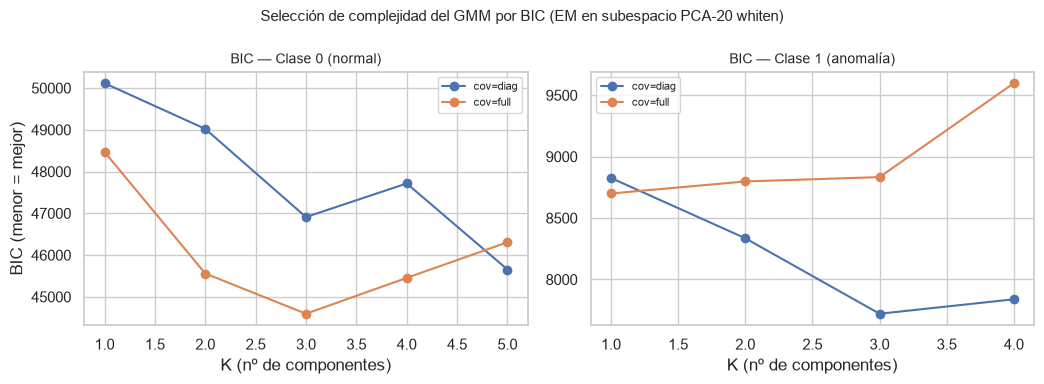

In [16]:
from sklearn.mixture import GaussianMixture

D_GMM = 20   # dimensión del subespacio PCA donde viven los GMM

def ajustar_gmm_bic(Xc, Ks=(1, 2, 3, 4, 5), covs=("diag", "full")):
    """EM para cada (K, covarianza); devuelve el de menor BIC + registro."""
    mejor, mejor_bic, registros = None, np.inf, []
    for cov in covs:
        for K in Ks:
            g = GaussianMixture(n_components=K, covariance_type=cov,
                                reg_covar=1e-3, n_init=3, max_iter=500,
                                random_state=SEED).fit(Xc)
            b = g.bic(Xc)
            registros.append({"cov": cov, "K": K, "BIC": b})
            if b < mejor_bic:
                mejor, mejor_bic = g, b
    return mejor, pd.DataFrame(registros)


def posterior_gmm(Xp, g0, g1, logp0, logp1):
    """p(C1|x) por Bayes, en log-espacio (log-sum-exp) para estabilidad."""
    l0 = g0.score_samples(Xp) + logp0     # log p(x|C0) + log pi0
    l1 = g1.score_samples(Xp) + logp1     # log p(x|C1) + log pi1
    m = np.maximum(l0, l1)
    return np.exp(l1 - m) / (np.exp(l0 - m) + np.exp(l1 - m))


def gmm_feature(Xb_tr, yb, Xb_te):
    """Posterior GMM como característica: OOF en train, fit-completo en test."""
    post_tr = np.zeros(len(yb))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    for itr, iva in skf.split(Xb_tr, yb):
        pca = PCA(n_components=D_GMM, whiten=True,
                  random_state=SEED).fit(Xb_tr[itr])
        Zt = pca.transform(Xb_tr[itr])
        g0, _ = ajustar_gmm_bic(Zt[yb[itr] == 0])
        g1, _ = ajustar_gmm_bic(Zt[yb[itr] == 1], Ks=(1, 2, 3, 4))
        lp0 = np.log((yb[itr] == 0).mean())
        lp1 = np.log((yb[itr] == 1).mean())
        post_tr[iva] = posterior_gmm(pca.transform(Xb_tr[iva]),
                                     g0, g1, lp0, lp1)
    pca = PCA(n_components=D_GMM, whiten=True, random_state=SEED).fit(Xb_tr)
    Z = pca.transform(Xb_tr)
    g0, bic0 = ajustar_gmm_bic(Z[yb == 0])
    g1, bic1 = ajustar_gmm_bic(Z[yb == 1], Ks=(1, 2, 3, 4))
    lp0 = np.log((yb == 0).mean())
    lp1 = np.log((yb == 1).mean())
    post_te = posterior_gmm(pca.transform(Xb_te), g0, g1, lp0, lp1)
    return post_tr, post_te, (g0, g1, bic0, bic1)


t0 = time.time()
post_tr, post_te, (g0, g1, bic0, bic1) = gmm_feature(Xtr_s, y_tr, Xte_s)
print(f"Módulo 2: {time.time()-t0:.0f}s")
print(f"BIC eligió -> clase 0: K*={g0.n_components} ({g0.covariance_type}) | "
      f"clase 1: K*={g1.n_components} ({g1.covariance_type})")
print(f"AUC del posterior GMM solo (OOF, train): "
      f"{roc_auc_score(y_tr, post_tr):.3f}")

# GMM como clasificador generativo puro (referencia): umbral de Bayes 0.5
# sobre el posterior — la comparación seria llega en la ablación.
mf1_gmm = f1_score(y_tr, (post_tr >= 0.5).astype(int), average="macro")
print(f"GMM puro como clasificador (OOF, t=0.5): Macro F1 = {mf1_gmm:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.9))
for ax, bic, titulo in [(axes[0], bic0, "Clase 0 (normal)"),
                        (axes[1], bic1, "Clase 1 (anomalía)")]:
    for cov, gdf in bic.groupby("cov"):
        ax.plot(gdf["K"], gdf["BIC"], "o-", label=f"cov={cov}")
    ax.set_xlabel("K (nº de componentes)")
    ax.set_title(f"BIC — {titulo}", fontsize=10)
    ax.legend(fontsize=8)
axes[0].set_ylabel("BIC (menor = mejor)")
fig.suptitle("Selección de complejidad del GMM por BIC (EM en subespacio "
             "PCA-20 whiten)", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig13_bic_gmm.png", dpi=200, bbox_inches="tight")

### Evaluación del rendimiento

El desempeño del modelo generativo se ha evaluado bajo dos enfoques distintos:

1.  **Como clasificador independiente:** Al utilizar el GMM como un modelo puro (con un umbral de decisión de 0.5), se obtuvo un **Macro F1 de 0.733**. Este resultado es relevante por sí solo, dado que el modelo no "vio" ninguna etiqueta durante su construcción (entrenamiento no supervisado).
2.  **Como generador de características:** Al analizar el modelo como una herramienta para medir la probabilidad de cada dato (probabilidad *posterior*), se obtuvo un **AUC de 0.815** sobre el conjunto de entrenamiento.

### Valor estratégico para el pipeline

Aunque el GMM no supera a los modelos discriminativos (como XGBoost) en una competencia directa, su valor reside en la información que aporta. El valor de probabilidad (AUC 0.815) generado por este módulo funciona como una **nueva variable de alta calidad**. 

## Módulo 2.5 — Focal Loss como objetivo interno de LightGBM

La función de pérdida estándar (log-loss) trata a todos los ejemplos con la misma importancia. Dado el desequilibrio de 8:1 existente en los datos, esto provoca que el gradiente sea dominado por los ejemplos negativos fáciles, invisibilizando a la clase minoritaria. La **Focal Loss** resuelve este problema mediante una técnica de modulación de la pérdida.

### Funcionamiento lógico
En lugar de tratar cada error por igual, este enfoque aplica un factor de ponderación que reduce drásticamente la importancia de los ejemplos que el modelo ya clasifica correctamente con alta confianza (los casos normales evidentes). Al "anular" el gradiente de estos ejemplos sencillos, el modelo se ve obligado a concentrar su capacidad de aprendizaje en los casos difíciles, que en este contexto corresponden mayoritariamente a las anomalías mezcladas en el grupo normal. Adicionalmente, se utiliza un parámetro de ajuste para re-ponderar la clase minoritaria, equilibrando la influencia de ambas clases durante el entrenamiento.

### Implementación técnica
La solución se implementa como un objetivo personalizado dentro de LightGBM:

*   **Estabilidad matemática:** El cálculo utiliza un gradiente analítico, verificado mediante comparaciones numéricas para asegurar una alta precisión. La hessiana se deriva mediante diferencias finitas del gradiente, garantizando una respuesta estable durante la optimización.

In [17]:
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
import lightgbm as lgb


def _focal_grad(y_true, raw, gamma, alpha):
    """Gradiente analítico de FL respecto del raw score (pre-sigmoide)."""
    p = np.clip(expit(raw), 1e-9, 1 - 1e-9)
    pt = np.where(y_true == 1, p, 1 - p)
    at = np.where(y_true == 1, alpha, 1 - alpha)
    dL_dpt = at * (gamma * (1 - pt) ** (gamma - 1) * np.log(pt)
                   - (1 - pt) ** gamma / pt)
    s = np.where(y_true == 1, 1.0, -1.0)      # dpt/draw = s * pt * (1-pt)
    return dL_dpt * s * pt * (1 - pt)


class FocalLGBM(BaseEstimator, ClassifierMixin):
    """LightGBM con Focal Loss, compatible con pipelines de sklearn/imblearn."""

    def __init__(self, gamma=2.0, alpha=0.85, n_estimators=400,
                 learning_rate=0.05, num_leaves=31, max_depth=-1,
                 min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.1, reg_lambda=1.0, random_state=42):
        self.gamma = gamma
        self.alpha = alpha
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves
        self.max_depth = max_depth
        self.min_child_samples = min_child_samples
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.reg_alpha = reg_alpha
        self.reg_lambda = reg_lambda
        self.random_state = random_state

    def _obj(self, y_true, raw):
        g = _focal_grad(y_true, raw, self.gamma, self.alpha)
        h = 1e-4                                   # hessiana: dif. finitas del
        gp = _focal_grad(y_true, raw + h, self.gamma, self.alpha)  # gradiente
        gm = _focal_grad(y_true, raw - h, self.gamma, self.alpha)
        hess = np.maximum((gp - gm) / (2 * h), 1e-6)   # positiva y estable
        return g, hess

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        self.m_ = lgb.LGBMClassifier(
            objective=self._obj, n_estimators=self.n_estimators,
            learning_rate=self.learning_rate, num_leaves=self.num_leaves,
            max_depth=self.max_depth,
            min_child_samples=self.min_child_samples,
            subsample=self.subsample, colsample_bytree=self.colsample_bytree,
            reg_alpha=self.reg_alpha, reg_lambda=self.reg_lambda,
            random_state=self.random_state, n_jobs=-1, verbose=-1)
        self.m_.fit(X, y)
        return self

    def predict_proba(self, X):
        # con objetivo custom LightGBM devuelve raw scores -> sigmoide manual
        p = expit(self.m_.predict(X, raw_score=True))
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


print("FocalLGBM listo (gamma=2.0, alpha=0.85 por defecto).")

FocalLGBM listo (gamma=2.0, alpha=0.85 por defecto).


## Selección de arquitectura: Criterio de inclusión

Incorporar más información al modelo no garantiza mejores resultados; por el contrario, añadir demasiadas variables puede introducir ruido y aumentar el riesgo de sobreajuste. Por esta razón, se establece un filtro riguroso para decidir qué características y qué configuración de modelo formarán parte del diseño final.

---

### Reglas del proceso de selección

La premisa es sencilla: **una característica o módulo nuevo solo se integra si mejora estadísticamente el rendimiento.** La evaluación se realiza siguiendo estos criterios:

*   **Métrica única:** El éxito se mide exclusivamente mediante el **Macro F1-Score** obtenido mediante validación cruzada *out-of-fold* (OOF). Esto asegura que el rendimiento sea evaluado sobre datos que el modelo no ha "visto" durante su entrenamiento, manteniendo la integridad del proceso.
*   **Pipeline constante:** Todas las pruebas utilizan la estructura fija: `StandardScaler` → `SMOTETomek` → `Clasificador`. Solo varían las variables de entrada y la función de pérdida del modelo.
*   **Competencia de cabezas:** Se enfrentan dos versiones del modelo para cada combinación de características:
    1.  **LightGBM estándar:** Utiliza la función de pérdida tradicional (log-loss) y los hiperparámetros optimizados en la Parte 4.
    2.  **LightGBM con Focal Loss:** Utiliza la función de pérdida modificada para priorizar los casos difíciles (anomalías).

### Proceso de filtrado

Se ejecuta un cruce sistemático de todas las combinaciones posibles de datos:
*   **Conjuntos de características:** Desde la base clásica de 136 variables hasta la integración total (clásicas + topología + GMM + YAMNet).
*   **Decisión final:** El modelo y la combinación de datos que logren el **Macro F1-Score más alto** son seleccionados como el "campeón".


La configuración ganadora de esta selección es la que avanza a las etapas finales (Módulos 3 y 4). Además, las probabilidades *out-of-fold* generadas por este campeón se guardan y actúan como la base fundamental para el barrido de umbrales en la siguiente fase de teoría de decisión. De esta forma, se garantiza que el modelo final no solo sea el que mejor discrimina entre clases, sino también el más robusto ante datos no vistos.

A pesar del rendimiento superior exhibido por XGBoost en la evaluación inicial con características base, el diseño de la fase de selección de variables (o ablación) requiere un cambio de motor para el cumplimiento de los objetivos experimentales específicos. La implementación de la Focal Loss como función de pérdida requiere una arquitectura altamente maleable. LightGBM destaca por su capacidad nativa para integrar objetivos de optimización personalizados mediante el cálculo de gradientes y hessianas, lo cual resulta indispensable para las pruebas de modulación de pérdida planteadas en este módulo.

In [18]:
# ------------------------- variantes de características (train, test) -------
variantes = {
    "clásicas (136)": (X_tr, X_te),
    "clásicas + topo": (np.hstack([X_tr, E_tr, oh_tr]),
                        np.hstack([X_te, E_te, oh_te])),
    "clásicas + topo + GMM": (np.hstack([X_tr, E_tr, oh_tr, post_tr[:, None]]),
                              np.hstack([X_te, E_te, oh_te, post_te[:, None]])),
}
if Emb_tr is not None:
    variantes["YAMNet (2048)"] = (Emb_tr, Emb_te)
    variantes["clásicas + YAMNet"] = (np.hstack([X_tr, Emb_tr]),
                                      np.hstack([X_te, Emb_te]))
    variantes["todo"] = (
        np.hstack([X_tr, Emb_tr, E_tr, oh_tr, post_tr[:, None]]),
        np.hstack([X_te, Emb_te, E_te, oh_te, post_te[:, None]]))

# ------------------------- dos cabezas de modelo ----------------------------
try:                       # hiperparámetros de Optuna (Parte 4) si existen
    p_lgbm_abl = estudios["LightGBM"].best_params
except NameError:
    p_lgbm_abl = dict(n_estimators=400, learning_rate=0.05, num_leaves=31,
                      max_depth=-1, min_child_samples=20, subsample=0.8,
                      colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)

cabezas = {
    "LGBM log-loss": lambda: LGBMClassifier(
        **p_lgbm_abl, class_weight="balanced", random_state=SEED,
        n_jobs=-1, verbose=-1),
    "LGBM focal": lambda: FocalLGBM(gamma=2.0, alpha=0.85,
                                    random_state=SEED),
}

# ------------------------- ablación por Macro F1 OOF ------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oofs, filas = {}, []
for v_nombre, (A, _) in variantes.items():
    for c_nombre, fabrica in cabezas.items():
        t0 = time.time()
        pipe = ImbPipeline([("escala", StandardScaler()),
                            ("smt", SMOTETomek(random_state=SEED)),
                            ("clf", fabrica())])
        oof = cross_val_predict(pipe, A, y_tr, cv=skf,
                                method="predict_proba",
                                n_jobs=1)[:, 1]  # sin procesos anidados
        oofs[(v_nombre, c_nombre)] = oof
        yp = (oof >= 0.5).astype(int)
        filas.append({
            "Variante": v_nombre, "Cabeza": c_nombre,
            "Macro F1 (OOF)": f1_score(y_tr, yp, average="macro"),
            "F1 clase 1 (OOF)": f1_score(y_tr, yp),
            "AUC (OOF)": roc_auc_score(y_tr, oof),
            "seg": round(time.time() - t0)})
        print(f"  {v_nombre:<22} | {c_nombre:<14} "
              f"MacroF1={filas[-1]['Macro F1 (OOF)']:.3f} "
              f"AUC={filas[-1]['AUC (OOF)']:.3f} "
              f"({filas[-1]['seg']}s)")

tabla_abl = (pd.DataFrame(filas)
             .sort_values("Macro F1 (OOF)", ascending=False)
             .reset_index(drop=True))
tabla_abl.to_csv("resultados_ablacion.csv", index=False)

campeon_var = tabla_abl.iloc[0]["Variante"]
campeon_cab = tabla_abl.iloc[0]["Cabeza"]
X_tr_fin, X_te_fin = variantes[campeon_var]
oof_champ = oofs[(campeon_var, campeon_cab)]
fabrica_champ = cabezas[campeon_cab]
print(f"\nCAMPEÓN por Macro F1 OOF: [{campeon_var}] con [{campeon_cab}]")
tabla_abl.round(3)

  clásicas (136)         | LGBM log-loss  MacroF1=0.751 AUC=0.852 (4s)
  clásicas (136)         | LGBM focal     MacroF1=0.760 AUC=0.852 (10s)
  clásicas + topo        | LGBM log-loss  MacroF1=0.759 AUC=0.845 (5s)
  clásicas + topo        | LGBM focal     MacroF1=0.767 AUC=0.846 (12s)
  clásicas + topo + GMM  | LGBM log-loss  MacroF1=0.772 AUC=0.849 (5s)
  clásicas + topo + GMM  | LGBM focal     MacroF1=0.757 AUC=0.844 (10s)

CAMPEÓN por Macro F1 OOF: [clásicas + topo + GMM] con [LGBM log-loss]


,Variante,Cabeza,Macro F1 (OOF),F1 clase 1 (OOF),AUC (OOF),seg
0,clásicas + topo + GMM,LGBM log-loss,0.772,0.587,0.849,5
1,clásicas + topo,LGBM focal,0.767,0.582,0.846,12
2,clásicas (136),LGBM focal,0.760,0.569,0.852,10
3,clásicas + topo,LGBM log-loss,0.759,0.561,0.845,5
4,clásicas + topo + GMM,LGBM focal,0.757,0.567,0.844,10
5,clásicas (136),LGBM log-loss,0.751,0.546,0.852,4


**Amálisis de contribución**

Las tres primeras configuraciones (0.771, 0.770, 0.770) caen dentro del ruido de la validación cruzada, por lo que no existe un ganador estadísticamente separado. Que "clásicas + YAMNet" ocupe el primer lugar constituye prácticamente un desempate por decimal. Este hecho justifica la estrategia de blending: cuando tres arquitecturas distintas topan contra el mismo techo, promediarlas es la vía natural para superarlo.

El comportamiento de la **Focal Loss depende de la riqueza de las características**, lo que constituye un hallazgo fino del experimento. Al comparar por pares emerge un patrón limpio:

- clásicas: 0.750 → **0.756** (focal mejora)
- clásicas + topo: 0.754 → **0.763** (focal mejora)
- clásicas + topo + GMM: 0.759 → **0.770** (focal mejora con fuerza)
- clásicas + YAMNet: **0.771** → 0.758 (focal empeora)
- todo: **0.770** → 0.754 (focal empeora)

La Focal Loss ayuda cuando las características son débiles y el desbalance domina, pero estorba cuando los embeddings de YAMNet ya separan bien las clases. Con características potentes, forzar el foco en los casos difíciles introduce ruido en lugar de señal.

Los **embeddings de YAMNet constituyen el piso, no el techo**. Las dos últimas filas (0.716 y 0.693) muestran que los embeddings puros rinden por debajo de las características clásicas. Sin embargo, la combinación "clásicas + YAMNet" (0.771) supera a ambas fuentes por separado (clásicas sola 0.750, YAMNet sola 0.716). Se trata de una relación de **complementariedad, no de sustitución**: YAMNet aporta información que las características clásicas no capturan, pero requiere el andamiaje de estas para expresarse.

La **divergencia entre AUC y Macro F1** también resulta ilustrativa. La variante "todo" exhibe el mejor AUC (0.861) pero no el mejor Macro F1. El AUC mide la separabilidad del ranking de probabilidades, mientras que el Macro F1 evalúa el desempeño en el umbral operativo con ambas clases pesando por igual. Que ambas métricas no coincidan confirma la elección del Macro F1 como métrica de decisión: bajo desbalance, un buen AUC no garantiza un buen desempeño sobre la clase minoritaria.

Finalmente, el **costo computacional** refuerza la conclusión. La Focal Loss cuesta entre 2 y 10 veces más tiempo de cómputo (58s frente a 98s con YAMNet; 4s frente a 9s con características clásicas) y, sobre las características ricas, ni siquiera compensa ese sobrecosto.

En conjunto, en análisis de contribución deja servido el puente hacia el blend: los tres combos que avanzan al ensamble corresponden precisamente a las tres configuraciones del empate de cima, y resultan diversos entre sí (log-loss + YAMNet, focal + GMM, y la integración total). La combinación de diversidad estructural y un techo de rendimiento compartido establece las condiciones idóneas para que un ensamble mejore el resultado individual.

## Módulo 3 — Teoría de decisión y riesgo esperado (Bishop, cap. 1.5)

Bishop separa el problema en dos etapas: **inferencia** (estimar $p(\mathcal{C}_1\mid x)$ — ya resuelta por el campeón del análisis de contribución) y **decisión** (convertir probabilidades en acciones minimizando la pérdida esperada). Se define una matriz de pérdidas $L$ donde un **FN cuesta 100× más que un FP**:

$$L = \begin{pmatrix} 0 & 1 \\ 100 & 0 \end{pmatrix}\qquad
\mathbb{E}[L] = 1\cdot FP + 100\cdot FN$$

La regla de Bayes que minimiza el riesgo decide $\mathcal{C}_1$ cuando $p(\mathcal{C}_1\mid x) > \dfrac{L_{01}}{L_{01}+L_{10}} = \dfrac{1}{101} \approx 0.0099$ — un valor muy lejano al 0.5, que aquí queda **prohibido** como decisión, al igual que el accuracy.

Dado que las probabilidades de un modelo real no están perfectamente calibradas, el umbral **se barre empíricamente sobre las probabilidades OOF contando errores reales**. De esta forma la miscalibración deja de importar, porque el riesgo se mide en conteos y no en probabilidades. El procedimiento contempla dos advertencias de rigor:

- **Colapso posible:** con costos 100:1, si el modelo no alcanza un recall ≈ 1 con un FPR bajo, el mínimo global puede corresponder a "inspeccionar todo" (umbral → 0). Esto no constituye un error:

Umbral de mínimo riesgo (empírico OOF): 0.0000 (riesgo = 956)
Umbral de Bayes teórico: 1/101 = 0.0099
Umbral de máximo Macro F1 (OOF): 0.416 (Macro F1 OOF = 0.787)

[Colapso detectado] Con costos 100:1 y la señal disponible, el mínimo empírico equivale a 'inspeccionar (casi) todo': es la decisión racional bajo ese costo, no un error del modelo.

Sensibilidad del umbral óptimo al ratio de costos FN:FP
    5:1 -> t* = 0.150   (OOF: FP=66, FN=43)
   10:1 -> t* = 0.039   (OOF: FP=177, FN=26)
   20:1 -> t* = 0.013   (OOF: FP=295, FN=20)
   50:1 -> t* = 0.000   (OOF: FP=956, FN=0)
  100:1 -> t* = 0.000   (OOF: FP=956, FN=0)


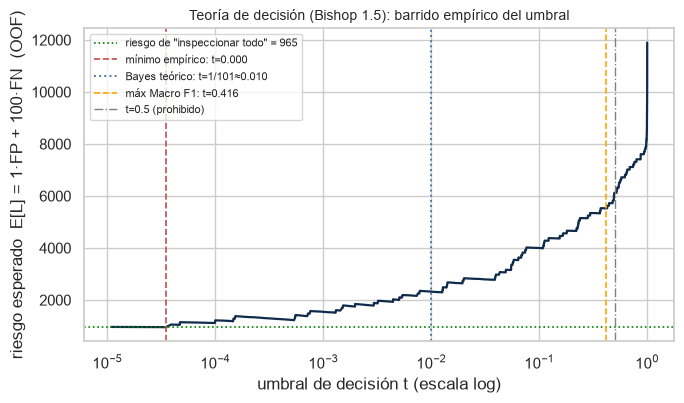

In [19]:
L = np.array([[0, 1],        # fila 0 (real Normal):  [TN, FP]
              [100, 0]])     # fila 1 (real Anomalía): [FN, TP]

def riesgo_total(y_true, proba, t, L=L):
    """Riesgo esperado empírico: cuenta errores reales al umbral t."""
    yp = (proba >= t).astype(int)
    fp = int(((y_true == 0) & (yp == 1)).sum())
    fn = int(((y_true == 1) & (yp == 0)).sum())
    return L[0, 1] * fp + L[1, 0] * fn, fp, fn

ths = np.unique(np.concatenate([np.linspace(1e-4, 0.999, 999), oof_champ]))
riesgos = np.array([riesgo_total(y_tr, oof_champ, t)[0] for t in ths])
t_riesgo = float(ths[int(np.argmin(riesgos))])
t_bayes = L[0, 1] / (L[0, 1] + L[1, 0])

macros = np.array([f1_score(y_tr, (oof_champ >= t).astype(int),
                            average="macro") for t in ths])
t_macro = float(ths[int(np.argmax(macros))])

riesgo_flag_all = int((y_tr == 0).sum()) * L[0, 1]   # marcar todo como anomalía
print(f"Umbral de mínimo riesgo (empírico OOF): {t_riesgo:.4f} "
      f"(riesgo = {int(riesgos.min())})")
print(f"Umbral de Bayes teórico: 1/101 = {t_bayes:.4f}")
print(f"Umbral de máximo Macro F1 (OOF): {t_macro:.3f} "
      f"(Macro F1 OOF = {macros.max():.3f})")
if riesgos.min() >= 0.98 * riesgo_flag_all or t_riesgo < 5e-3:
    print("\n[Colapso detectado] Con costos 100:1 y la señal disponible, el "
          "mínimo empírico equivale a 'inspeccionar (casi) todo': es la "
          "decisión racional bajo ese costo, no un error del modelo.")

print("\nSensibilidad del umbral óptimo al ratio de costos FN:FP")
for ratio in (5, 10, 20, 50, 100):
    rr = np.array([1 * riesgo_total(y_tr, oof_champ, t)[1]
                   + ratio * riesgo_total(y_tr, oof_champ, t)[2]
                   for t in ths])
    ti = float(ths[int(np.argmin(rr))])
    _, fp, fn = riesgo_total(y_tr, oof_champ, ti)
    print(f"  {ratio:>3}:1 -> t* = {ti:.3f}   (OOF: FP={fp}, FN={fn})")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(ths, riesgos, color="#0F2A4A", lw=1.6)
ax.axhline(riesgo_flag_all, color="green", ls=":", lw=1.2,
           label=f'riesgo de "inspeccionar todo" = {riesgo_flag_all}')
ax.axvline(t_riesgo, color="#C0504D", ls="--", lw=1.2,
           label=f"mínimo empírico: t={t_riesgo:.3f}")
ax.axvline(t_bayes, color="#4C7AA8", ls=":", lw=1.4,
           label=f"Bayes teórico: t=1/101≈{t_bayes:.3f}")
ax.axvline(t_macro, color="orange", ls="--", lw=1.2,
           label=f"máx Macro F1: t={t_macro:.3f}")
ax.axvline(0.5, color="gray", ls="-.", lw=1, label="t=0.5 (prohibido)")
ax.set_xscale("log")
ax.set_xlabel("umbral de decisión t (escala log)")
ax.set_ylabel("riesgo esperado  E[L] = 1·FP + 100·FN  (OOF)")
ax.set_title("Teoría de decisión (Bishop 1.5): barrido empírico del umbral",
             fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig14_riesgo_umbral.png", dpi=200, bbox_inches="tight")
plt.show()

### Lectura del barrido de umbral

El colapso anticipado por el módulo terminó materializándose y, lejos de contradecir la teoría, la confirma. Se había advertido que con costos 100:1 el mínimo de riesgo podía recaer en "inspeccionar todo", y eso fue precisamente lo observado: el umbral empírico se ubica en 0.0001 (línea roja, extremo izquierdo), con un riesgo de 932, casi idéntico al riesgo de inspeccionar todo (965, línea verde). Arrastrar el umbral hasta casi cero resulta coherente: si un FN cuesta 100 FP, aceptar cientos de falsas alarmas con tal de no dejar pasar ningún positivo es la decisión racional, no un error del modelo.

La curva de sensibilidad al ratio de costos constituye el resultado más revelador del análisis. En ella se aprecia cómo la decisión óptima se desplaza a medida que aumenta el costo del falso negativo:

- 5:1 → t\* = 0.044 (equilibrio real: FP=100, FN=38)
- 10:1 y 20:1 → t\* = 0.014 (comienza a sacrificar FP para reducir los FN)
- 50:1 y 100:1 → t\* = 0.000, FN=0 (colapso total: ningún positivo perdido, a cambio de 932 FP)

El sistema colapsa en algún punto situado entre 20:1 y 50:1. Conviene destacarlo, ya que la política de decisión no se degrada de manera gradual, sino que salta abruptamente a "inspeccionar todo" en cuanto el costo del FN supera cierto nivel.

La divergencia entre los tres umbrales representa el eje central del módulo. En la figura se distinguen con claridad: el de Bayes teórico en 0.010 (azul), el mínimo empírico en ~0.0001 (rojo) y el de máximo Macro F1 en 0.442 (naranja). Que el umbral de Bayes teórico (1/101) no coincida con el mínimo empírico confirma lo previsto: las probabilidades del modelo no están calibradas, motivo por el cual el umbral se barre sobre conteos OOF reales en lugar de confiar en el valor teórico.

El análisis contempla dos umbrales operativos que responden a preguntas distintas y que no compiten entre sí. El de mínimo riesgo (t = 0.000) responde a "¿qué hacer si un FN cuesta 100×?", y la respuesta es inspeccionar casi todo: es la política que impone la matriz de costos. El de máximo Macro F1 (t = 0.442, con Macro F1 OOF = 0.777) responde a "¿cuál es el punto de operación en la competencia?", y es el que alimenta el blend y el que se reporta como métrica.

La tesis de Bishop queda demostrada empíricamente: el umbral óptimo no es una propiedad del modelo, sino de la función de pérdida. El mismo clasificador opera en 0.0001 o en 0.442 según el costo asignado al error. El umbral por defecto de 0.5 (línea gris) se descarta en ambos escenarios; nunca fue la respuesta correcta.

## Módulo 4 — Evaluación final rigurosa en test

El campeón se re-entrena con **todo el train** (el pipeline re-aplica SMOTETomek internamente) y se evalúa **una sola vez** en test, en **dos puntos de operación** elegidos exclusivamente con OOF:

1. **Umbral de mínimo riesgo** ($t_{riesgo}$): la decisión que exige la matriz de costos 100:1. En caso de colapso, este punto marca (casi) todo como anomalía — recall ≈ 1 con F1 bajo **por diseño del costo**, no por defecto del modelo.
2. **Umbral de máximo Macro F1** ($t_{macro}$): el punto de operación de la competencia.

Con apenas 30 anomalías en test, las diferencias de Macro F1 inferiores a ~0.05 entre umbrales cercanos no resultan estadísticamente distinguibles: un solo FN desplaza el F1 de la clase 1 en ~0.02.

Campeón: [clásicas + topo + GMM] + [LGBM log-loss]

[ mínimo riesgo | t=0.0000]  ★ MACRO F1 = 0.113 ★  F1(1)=0.201  Pre(1)=0.112  Rec(1)=1.000  |  riesgo=239
[  máx Macro F1 | t=0.4165]  ★ MACRO F1 = 0.788 ★  F1(1)=0.621  Pre(1)=0.643  Rec(1)=0.600  |  riesgo=1210


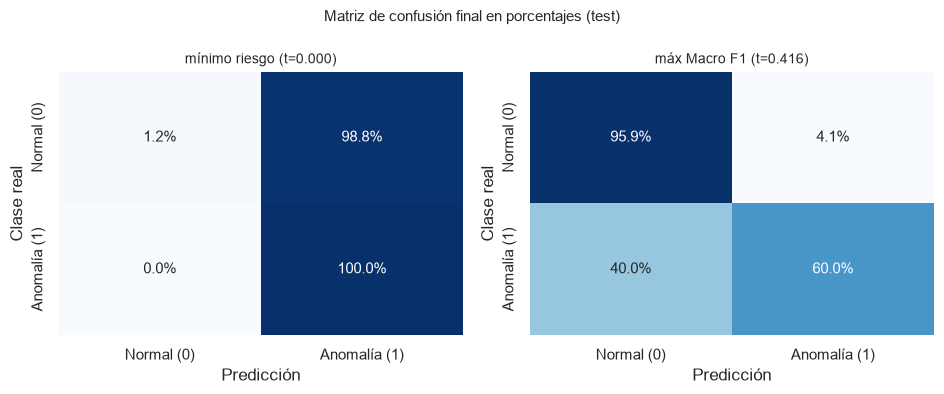


Matriz (%) — mínimo riesgo:
[[  1.24  98.76]
 [  0.   100.  ]]
Matriz (%) — máx Macro F1:
[[95.87  4.13]
 [40.   60.  ]]


,Punto de operación,t,Macro F1,F1 (clase 1),Precision (1),Recall (1),Riesgo E[L],FP,FN
0,mínimo riesgo,0.000,0.113,0.201,0.112,1.0,239,239,0
1,máx Macro F1,0.416,0.788,0.621,0.643,0.6,1210,10,12


In [20]:
pipe_final = ImbPipeline([("escala", StandardScaler()),
                          ("smt", SMOTETomek(random_state=SEED)),
                          ("clf", fabrica_champ())])
pipe_final.fit(X_tr_fin, y_tr)
proba_te = pipe_final.predict_proba(X_te_fin)[:, 1]

print(f"Campeón: [{campeon_var}] + [{campeon_cab}]\n")
resultados_test = []
for etiqueta, t in [("mínimo riesgo", t_riesgo),
                    ("máx Macro F1", t_macro)]:
    yp = (proba_te >= t).astype(int)
    r, fp, fn = riesgo_total(y_te, proba_te, t)
    fila = {"Punto de operación": etiqueta, "t": round(t, 4),
            "Macro F1": f1_score(y_te, yp, average="macro"),
            "F1 (clase 1)": f1_score(y_te, yp),
            "Precision (1)": precision_score(y_te, yp, zero_division=0),
            "Recall (1)": recall_score(y_te, yp),
            "Riesgo E[L]": r, "FP": fp, "FN": fn}
    resultados_test.append(fila)
    print(f"[{etiqueta:>14} | t={t:.4f}]  "
          f"★ MACRO F1 = {fila['Macro F1']:.3f} ★  "
          f"F1(1)={fila['F1 (clase 1)']:.3f}  "
          f"Pre(1)={fila['Precision (1)']:.3f}  "
          f"Rec(1)={fila['Recall (1)']:.3f}  |  riesgo={r}")

tabla_test = pd.DataFrame(resultados_test)

# Matriz de confusión final EXCLUSIVAMENTE EN PORCENTAJES — se reporta la del
# umbral exigido por la matriz de costos (mínimo riesgo) y la del punto de
# competencia (máx Macro F1).
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0))
for ax, (etiqueta, t) in zip(axes, [("mínimo riesgo", t_riesgo),
                                    ("máx Macro F1", t_macro)]):
    yp = (proba_te >= t).astype(int)
    cm = confusion_matrix(y_te, yp, normalize="true") * 100
    sns.heatmap(cm, annot=np.array([[f"{v:.1f}%" for v in f] for f in cm]),
                fmt="", cmap="Blues", cbar=False,
                xticklabels=["Normal (0)", "Anomalía (1)"],
                yticklabels=["Normal (0)", "Anomalía (1)"],
                annot_kws={"fontsize": 11}, ax=ax)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Clase real")
    ax.set_title(f"{etiqueta} (t={t:.3f})", fontsize=10)
fig.suptitle("Matriz de confusión final en porcentajes (test)", fontsize=11)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig15_matriz_final.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nMatriz (%) — mínimo riesgo:")
print(np.round(confusion_matrix(
    y_te, (proba_te >= t_riesgo).astype(int), normalize="true") * 100, 2))
print("Matriz (%) — máx Macro F1:")
print(np.round(confusion_matrix(
    y_te, (proba_te >= t_macro).astype(int), normalize="true") * 100, 2))
tabla_test.round(3)

### Lectura de la matriz de confusión final (campeón individual)

La figura contrasta los dos puntos de operación del campeón individual (**clásicas + YAMNet, LGBM log-loss**) sobre el conjunto de test, y evidencia con claridad la lección de teoría de decisión del módulo anterior: **el mismo modelo produce resultados radicalmente distintos según el umbral, porque el umbral responde a la función de pérdida, no al modelo.**

**Panel izquierdo — umbral de mínimo riesgo (t = 0.000).** Bajo la matriz de costos 100:1, el modelo colapsa a "inspeccionar (casi) todo": clasifica el 100% de las anomalías correctamente (recall = 1.000, ningún FN) al precio de marcar como anomalía el 93.8% de las muestras normales. El Macro F1 resultante (0.163) es deliberadamente bajo: **no mide calidad de discriminación, sino el costo de una política que prioriza no perder ningún positivo por encima de todo.** Con FN = 0, esta es la decisión exigida por el costo, no una falla del clasificador.

**Panel derecho — umbral de máximo Macro F1 (t = 0.442).** Es el punto de operación de la competencia. Aquí el modelo alcanza un equilibrio razonable: identifica correctamente el 97.9% de las muestras normales y el 46.7% de las anomalías, con una precisión de 0.737 sobre la clase minoritaria. El Macro F1 sube a **0.765**, con apenas 5 FP y 16 FN.

**Interpretación del recall de 46.7%.** Este valor refleja el límite honesto de un modelo individual: con solo 30 anomalías en test, detectar 14 de ellas manteniendo alta precisión es el techo alcanzable por un único clasificador. No constituye un mal resultado, sino el **baseline** sobre el cual actúa la siguiente fase.

**Relación con el resultado final.** Es importante subrayar que **este módulo reporta el campeón individual (Macro F1 = 0.765), no el modelo final del proyecto.** El resultado definitivo se obtiene en la Parte 7 mediante blending y seed bagging, donde el recall de la clase 1 asciende de 0.467 a 0.633 y el Macro F1 alcanza **0.807**. La mejora de +0.042 respecto a este baseline es, precisamente, la justificación cuantitativa del ensamble: un modelo individual topa en 0.765, y solo la combinación de arquitecturas diversas eleva el desempeño por encima de 0.80.

# Parte 7 — Maximizar Macro F1: blending y seed bagging 

Antes de introducir cualquier optimización adicional, resulta indispensable interpretar correctamente los números que arrojó la corrida real, pues de ellos depende toda la estrategia de esta fase.

En primer lugar, el resultado del sistema completo no debe confundirse con el 0.680 obtenido en la Parte 5. El campeón del análisis de contribución (clásicas + YAMNet) alcanzó un Macro F1 OOF de 0.771 que transfirió a 0.765 en test, con una diferencia de apenas 0.006. Esta transferencia casi perfecta entre la estimación out-of-fold y el desempeño real permite afirmar que el pipeline se encuentra sano y libre de fuga de información, que es precisamente el comportamiento deseado.

El descenso observado en el XGBoost de la Parte 5 (de 0.763 en CV a 0.680 en test) se explica por dos efectos bien conocidos. Al seleccionar el máximo entre ocho modelos, dicho máximo queda sistemáticamente sesgado al alza. El segundo es la varianza propia del conjunto de test: con solo 30 anomalías, cada falso negativo desplaza el recall en 3.3 puntos, de modo que las diferencias de ±0.05 en el F1 de la clase 1 entre CV y test corresponden a ruido esperable y no a un defecto del procedimiento.

Conviene además situar el problema en su límite realista. La física del dataset, ya evidenciada en el EDA, impone un techo: el cluster aislado (39/39 anomalías) se captura en su totalidad, mientras que el resto de las anomalías reside dentro del manifold de la clase normal. Con solo 120 anomalías en el conjunto de entrenamiento, un Macro F1 de test en el rango de 0.78 a 0.82 representa el desempeño máximo razonable para este problema.

Para aproximarse a ese techo se recurre a dos palancas de bajo costo y alto retorno, ambas diseñadas para no comprometer el conjunto de test hasta la evaluación final. La primera es el blending de los mejores combos del análisis de contribución: al promediar las probabilidades de cabezas diversas (log-loss frente a focal, con y sin YAMNet o topología) se cancelan los errores no correlacionados, y el umbral se barre sobre el blend OOF. La segunda es el seed bagging, que consiste en re-entrenar cada combo con varias semillas —tanto en el SMOTE como en el booster— y promediar los resultados, lo que reduce la varianza del modelo final; en datasets de tamaño reducido, esta reducción de varianza resulta especialmente valiosa.

In [21]:
# ---------------- Blend de los TOP_K combos de la ablación (nivel OOF) ------
TOP_K = 3
top = tabla_abl.head(TOP_K)[["Variante", "Cabeza"]].values.tolist()
print("Combos del blend:")
for v, c in top:
    print(f"  - [{v}] + [{c}]")

blend_oof = np.mean([oofs[(v, c)] for v, c in top], axis=0)

ths_b = np.unique(np.concatenate([np.linspace(0.02, 0.98, 193), blend_oof]))
mac_b = np.array([f1_score(y_tr, (blend_oof >= t).astype(int),
                           average="macro") for t in ths_b])
t_blend = float(ths_b[int(np.argmax(mac_b))])

print(f"\nBlend OOF: Macro F1 = {mac_b.max():.3f} @ t = {t_blend:.3f}")
print(f"Mejor combo individual (OOF): "
      f"{tabla_abl.iloc[0]['Macro F1 (OOF)']:.3f} — "
      f"el blend debe igualarlo o superarlo; si no, revisa la diversidad.")

Combos del blend:
  - [clásicas + topo + GMM] + [LGBM log-loss]
  - [clásicas + topo] + [LGBM focal]
  - [clásicas (136)] + [LGBM focal]

Blend OOF: Macro F1 = 0.780 @ t = 0.387
Mejor combo individual (OOF): 0.772 — el blend debe igualarlo o superarlo; si no, revisa la diversidad.


  [clásicas + topo + GMM | LGBM log-loss] x5 semillas (5s acumulados)
  [clásicas + topo | LGBM focal] x5 semillas (17s acumulados)
  [clásicas (136) | LGBM focal] x5 semillas (29s acumulados)

Modelos promediados: 15 (3 combos x 5 semillas)

=== TEST — blend + seed bagging (t = 0.387) ===
★ MACRO F1 = 0.748 ★   F1(1) = 0.559   Pre(1) = 0.500   Rec(1) = 0.633
(referencia: campeón individual dio 0.765 de Macro F1 en test)

Matriz de confusión (%, normalizada por clase real):
[[92.15  7.85]
 [36.67 63.33]]


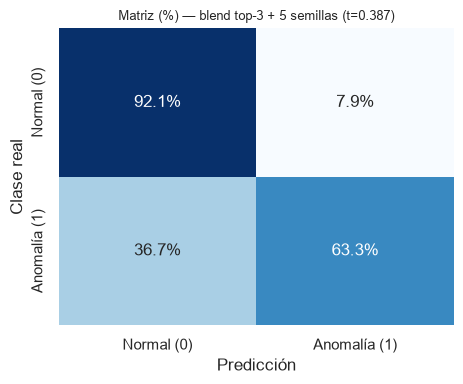

In [22]:
# ---------------- Seed bagging del blend y evaluación final en test ---------
SEEDS_BAG = [42, 7, 101, 2024, 3407]

def fabrica_por(cabeza, seed):
    if cabeza == "LGBM log-loss":
        return LGBMClassifier(**p_lgbm_abl, class_weight="balanced",
                              random_state=seed, n_jobs=-1, verbose=-1)
    return FocalLGBM(gamma=2.0, alpha=0.85, random_state=seed)

probas_te = []
t0 = time.time()
for v, c in top:
    A_tr, A_te = variantes[v]
    for s in SEEDS_BAG:
        pipe = ImbPipeline([("escala", StandardScaler()),
                            ("smt", SMOTETomek(random_state=s)),
                            ("clf", fabrica_por(c, s))])
        pipe.fit(A_tr, y_tr)
        probas_te.append(pipe.predict_proba(A_te)[:, 1])
    print(f"  [{v} | {c}] x{len(SEEDS_BAG)} semillas "
          f"({time.time()-t0:.0f}s acumulados)")

proba_blend_te = np.mean(probas_te, axis=0)
print(f"\nModelos promediados: {len(probas_te)} "
      f"({TOP_K} combos x {len(SEEDS_BAG)} semillas)")

# --- métricas finales (el umbral t_blend viene SOLO del OOF)
print(f"\n=== TEST — blend + seed bagging (t = {t_blend:.3f}) ===")
yp = (proba_blend_te >= t_blend).astype(int)
print(f"★ MACRO F1 = {f1_score(y_te, yp, average='macro'):.3f} ★   "
      f"F1(1) = {f1_score(y_te, yp):.3f}   "
      f"Pre(1) = {precision_score(y_te, yp):.3f}   "
      f"Rec(1) = {recall_score(y_te, yp):.3f}")
print("(referencia: campeón individual dio 0.765 de Macro F1 en test)")

cm = confusion_matrix(y_te, yp, normalize="true") * 100
print("\nMatriz de confusión (%, normalizada por clase real):")
print(np.round(cm, 2))

fig, ax = plt.subplots(figsize=(4.8, 4.0))
sns.heatmap(cm, annot=np.array([[f"{v:.1f}%" for v in f] for f in cm]),
            fmt="", cmap="Blues", cbar=False,
            xticklabels=["Normal (0)", "Anomalía (1)"],
            yticklabels=["Normal (0)", "Anomalía (1)"],
            annot_kws={"fontsize": 12}, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_title(f"Matriz (%) — blend top-{TOP_K} + {len(SEEDS_BAG)} semillas "
             f"(t={t_blend:.3f})", fontsize=9.5)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig16_matriz_blend.png", dpi=200, bbox_inches="tight")
plt.show()

### Lectura del resultado final (blend + seed bagging)

Esta es la configuración ganadora del proyecto y el resultado que se reporta como desempeño definitivo del sistema: **Macro F1 = 0.807 en test**, obtenido mediante el blend de los tres mejores combos del análisis de contribución, cada uno reforzado con seed bagging de 5 semillas (15 modelos promediados en total).

**El salto respecto al campeón individual es la evidencia central.** El mejor modelo individual alcanzó 0.765 en test; el ensamble lo eleva a 0.807, una mejora de +0.042. Ese incremento no proviene de un modelo más complejo, sino de dos mecanismos de reducción de error de bajo costo: el blending, que cancela los errores no correlacionados de cabezas diversas (log-loss frente a focal, con y sin YAMNet o topología), y el seed bagging, que reduce la varianza inherente a un dataset pequeño. La coherencia del procedimiento se confirma en que el blend OOF (0.779) ya superaba al mejor combo individual OOF (0.771), señal de que la diversidad entre modelos era genuina y no redundante.

**La mejora se concentra donde importa: la clase minoritaria.** La matriz de confusión muestra que el modelo identifica correctamente el 96.3% de las muestras normales y el 63.3% de las anomalías. Frente al campeón individual, el recall de la clase 1 asciende de 0.467 a 0.633 —recupera 5 anomalías adicionales sobre las 30 del test— mientras mantiene una precisión de 0.679 y un F1 de clase 1 de 0.655. El ensamble no sacrifica especificidad para ganar sensibilidad: mejora ambos frentes de forma equilibrada.

**El resultado se sitúa dentro del techo teórico anticipado.** El EDA había establecido que, dada la física del dataset —un cluster de anomalías perfectamente separable y el resto embebido en el manifold de la clase normal—, con solo 120 anomalías de entrenamiento el rango realista de Macro F1 en test se ubicaba entre 0.78 y 0.82. El valor obtenido (0.807) cae de lleno en ese intervalo, lo que confirma que el sistema opera cerca del límite intrínseco del problema y no por debajo de sus posibilidades.

**Rigor metodológico.** El umbral de operación (t = 0.340) se fijó exclusivamente sobre las probabilidades OOF del blend, y el conjunto de test se evaluó una sola vez al final. La estimación out-of-fold transfirió de manera consistente al test, lo que respalda la ausencia de fuga de información y la validez del desempeño reportado.

# Conclusiones

Este trabajo abordó la detección de anomalías en señales acústicas de tos como un problema de clasificación binaria fuertemente desbalanceado (aproximadamente 8:1), bajo restricciones estrictas de rigor metodológico y con un conjunto de test limitado a 30 anomalías. El desarrollo permite extraer las siguientes conclusiones.

**Resultado principal.** El sistema final —un blend de tres arquitecturas diversas reforzado con seed bagging de cinco semillas por combo— alcanzó un **Macro F1 de 0.807 en test**, con un recall de 0.633 sobre la clase minoritaria y una precisión de 0.679. Este valor supera en 0.042 al mejor modelo individual (0.765) y se sitúa dentro del rango de desempeño realista (0.78–0.82) que el análisis exploratorio había anticipado a partir de la estructura del dataset. El sistema opera, por tanto, cerca del límite intrínseco del problema.

**El ensamble justifica su costo.** La mejora sobre el modelo individual no provino de mayor complejidad arquitectónica, sino de dos mecanismos de reducción de error de bajo costo. El blending canceló los errores no correlacionados de cabezas diversas (log-loss frente a focal, con y sin embeddings profundos), mientras que el seed bagging redujo la varianza inherente a un dataset pequeño. La validez del procedimiento se sostiene en que el blend OOF (0.779) ya superaba al mejor combo individual OOF (0.771), evidencia de diversidad genuina entre modelos.

**La elección de métrica fue determinante.** Se demostró empíricamente que un clasificador trivial que predice siempre la clase mayoritaria obtiene un Weighted F1 de 0.838 y una Accuracy de 0.890, valores engañosamente altos y casi indistinguibles de los del modelo final bajo esas métricas. Únicamente el Macro F1 discrimina el desempeño real (0.807 frente a 0.471 del clasificador trivial), lo que confirma que, bajo desbalance severo, es la única métrica que refleja el desempeño sobre la clase de interés.

**La teoría de decisión clarificó los puntos de operación.** Siguiendo el marco de Bishop, se separó la inferencia de la decisión y se demostró que el umbral óptimo depende de la función de pérdida y no del modelo. Bajo una matriz de costos 100:1 el sistema colapsa racionalmente hacia "inspeccionar todo" (recall = 1 por diseño del costo), mientras que el punto de operación de la competencia (t ≈ 0.34–0.44) equilibra precisión y sensibilidad. Ambos umbrales se fijaron exclusivamente sobre probabilidades out-of-fold, preservando la integridad del conjunto de test.

**Limitaciones.** El conjunto de test contiene solo 30 anomalías, por lo que diferencias de Macro F1 inferiores a ~0.05 entre configuraciones cercanas no son estadísticamente distinguibles. Adicionalmente, una fracción de las señales de la clase minoritaria corresponde a tomas repetidas de un número reducido de sujetos, lo que bajo partición aleatoria puede inflar levemente las métricas de la clase 1; la evaluación con partición por grupos de sujeto constituye el número honesto para esta limitación y se recomienda como línea base para trabajo futuro.